Importando bibliotecas:

In [6]:
#Importar Bibliotecas
#carregando bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib
import json
from datetime import datetime


Fase 1: Análise Exploratória de Dados (EDA)

Estatística Descritiva: Apresente de forma explícita as dimensões do dataset (linhas e colunas), os tipos primitivos das variáveis carregadas e o resumo estatístico descritivo das colunas numéricas (usando o método .describe()).
Visualização de Dados: plote, no mínimo, 3 gráficos analíticos, por exemplo: histograma da distribuição da variável-alvo (avalie também sua assimetria), gráficos de dispersão entre ao menos duas variáveis explicativas e a variável-alvo, e um mapa de calor da correlação de Pearson entre as variáveis numéricas (retomando o conceito de multicolinearidade já trabalhado).
Análise Textual: insira uma célula de texto que explique, de forma crítica, os achados das análises visuais e estatísticas, indicando como esses padrões orientarão suas escolhas de modelagem (ou explique tudo isso no seu vídeo).


In [8]:
#carregando o dataset
df = pd.read_csv("../data/raw/spanish_houses.csv")

In [9]:
#dimensões do dataset
print("Número de linhas:", df.shape[0])
print("Número de colunas:", df.shape[1])

Número de linhas: 100000
Número de colunas: 41


In [10]:
#Tipos de variáveis e informações gerais do dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 41 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   ad_description                 95426 non-null   str    
 1   ad_last_update                 100000 non-null  str    
 2   air_conditioner                100000 non-null  str    
 3   balcony                        100000 non-null  str    
 4   bath_num                       100000 non-null  str    
 5   built_in_wardrobe              100000 non-null  str    
 6   chimney                        100000 non-null  str    
 7   condition                      86059 non-null   str    
 8   construct_date                 32059 non-null   str    
 9   energetic_certif               74691 non-null   str    
 10  floor                          79693 non-null   str    
 11  garage                         40811 non-null   str    
 12  garden                         100000 non-

In [11]:
#estatisticas descritivas do dataset
df.describe()

,number_of_companies_prov,population_prov,companies_prov_vs_national_%,population_prov_vs_national_%,renta_media_prov
count,100000.000000,1.000000e+05,100000.000000,100000.000000,59280.00000
mean,100050.342090,1.320589e+06,3.000553,2.827112,11864.35119
std,114436.597411,1.379332e+06,3.429043,2.952647,9980.43530
min,5689.000000,8.860000e+04,0.170000,0.190000,21.61300
25%,49582.000000,7.205920e+05,1.490000,1.540000,22.82200
50%,75628.000000,1.128908e+06,2.270000,2.420000,19818.00000
75%,96638.000000,1.149628e+06,2.900000,2.460000,19818.00000
max,538917.000000,6.578079e+06,16.150000,14.080000,21714.00000


In [12]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ad_description,95426,86150,ad_description,183,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ad_last_update,100000,369,más de 5 meses sin actualizar,3208,NaN,NaN,NaN,NaN,NaN,NaN,NaN
air_conditioner,100000,3,0,76867,NaN,NaN,NaN,NaN,NaN,NaN,NaN
balcony,100000,3,0,81668,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bath_num,100000,30,2,40556,NaN,NaN,NaN,NaN,NaN,NaN,NaN
built_in_wardrobe,100000,3,0,57444,NaN,NaN,NaN,NaN,NaN,NaN,NaN
chimney,100000,3,0,96132,NaN,NaN,NaN,NaN,NaN,NaN,NaN
condition,86059,4,segunda mano/buen estado,72272,NaN,NaN,NaN,NaN,NaN,NaN,NaN
construct_date,32059,355,2007,1031,NaN,NaN,NaN,NaN,NaN,NaN,NaN
energetic_certif,74691,4,en trámite,46957,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
#valores ausentes por coluna
df.isnull().sum().sort_values(ascending=False)

ground_size                      99817
unfurnished                      99354
kitchen                          97788
loc_street                       85686
heating                          74286
construct_date                   67941
orientation                      60585
garage                           59189
loc_neigh                        56310
m2_useful                        47156
lift                             41035
renta_media_prov                 40720
energetic_certif                 25309
floor                            20307
condition                        13941
loc_district                     13747
ad_description                    4574
price                                0
population_prov_vs_national_%        0
companies_prov_vs_national_%         0
population_prov                      0
number_of_companies_prov             0
air_conditioner                      0
terrace                              0
swimming_pool                        0
storage_room             

In [14]:
#percentual de valores ausentes por coluna
percentual_nulos = (df.isnull().sum() / len(df)) * 100

nulos = pd.DataFrame({
    'Valores Nulos': df.isnull().sum(),
    'Percentual (%)': percentual_nulos.round(2)
})

nulos.sort_values('Percentual (%)', ascending=False)

,Valores Nulos,Percentual (%)
ground_size,99817,99.82
unfurnished,99354,99.35
kitchen,97788,97.79
loc_street,85686,85.69
heating,74286,74.29
construct_date,67941,67.94
orientation,60585,60.58
garage,59189,59.19
loc_neigh,56310,56.31
m2_useful,47156,47.16


## Análise Inicial

O conjunto de dados apresenta aproximadamente 100 mil registros contendo informações sobre imóveis localizados na Espanha. As variáveis incluem características físicas dos imóveis, localização, infraestrutura e indicadores socioeconômicos das províncias. A análise dos tipos de dados mostrou a presença de variáveis numéricas, categóricas e booleanas, sendo necessária a conversão de algumas colunas originalmente importadas como texto.

## Análise de valores ausentes

A análise dos valores ausentes mostrou que o conjunto de dados possui variáveis com diferentes níveis de completude. Observa-se que algumas colunas apresentam mais de 90% de informações ausentes, como **ground_size (99,82%)**, **unfurnished (99,35%)** e **kitchen (97,79%)**. Além disso, **loc_street (85,69%)** e **heating (74,29%)** também possuem um percentual elevado de valores nulos.

Considerando que essas variáveis possuem quantidade insuficiente de informações para representar adequadamente o conjunto de dados, optou-se por removê-las da análise. A manutenção dessas colunas exigiria imputações em larga escala, aumentando o risco de introduzir vieses e reduzindo a confiabilidade do modelo preditivo.

Algumas variáveis apresentam percentual intermediário de valores ausentes, como **construct_date (67,94%)**, **orientation (60,58%)**, **garage (59,19%)**, **loc_neigh (56,31%)**, **m2_useful (47,16%)** e **lift (41,04%)**. Essas colunas foram analisadas individualmente quanto à sua relevância para a previsão do preço dos imóveis. As variáveis consideradas importantes para o modelo foram mantidas e seus valores ausentes tratados por meio de técnicas de imputação adequadas ou criação da categoria "Não Informado", quando categóricas.

Por outro lado, variáveis com baixo percentual de dados ausentes, como **condition (13,94%)**, **loc_district (13,75%)** e **ad_description (4,57%)**, foram mantidas, pois a quantidade reduzida de valores faltantes permite um tratamento simples sem comprometer significativamente a qualidade das informações.

A variável-alvo **price** não apresenta valores ausentes, garantindo que todas as observações utilizadas no treinamento do modelo possuam o valor de referência a ser previsto. Da mesma forma, os indicadores socioeconômicos da província (**population_prov**, **companies_prov_vs_national_%** e **population_prov_vs_national_%**) estão completos, tornando-se candidatos importantes para a etapa de modelagem.


## Visualização de Dados:

Plote, no mínimo, 3 gráficos analíticos, por exemplo: histograma da distribuição da variável-alvo (avalie também sua assimetria), gráficos de dispersão entre ao menos duas variáveis explicativas e a variável-alvo, e um mapa de calor da correlação de Pearson entre as variáveis numéricas (retomando o conceito de multicolinearidade já trabalhado).


In [15]:
import os


os.makedirs("../outputs/figures", exist_ok=True)



In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df_tratado,
    x="price",
    bins=40,
    kde=True
)

plt.title("Distribuição do preço dos imóveis")
plt.xlabel("Preço")
plt.ylabel("Quantidade")

# Salva o gráfico
plt.savefig(
    "../outputs/figures/histograma_preco.png",
    dpi=300,
    bbox_inches="tight"
)

# Exibe o gráfico
plt.show()

plt.show()


## Anáilise descritiva:

A Figura apresenta a distribuição da variável-alvo (`price`) por meio de um histograma acompanhado de uma curva de densidade (Kernel Density Estimation – KDE). Observa-se uma elevada concentração de imóveis em faixas de menor preço, evidenciada pelo pico acentuado no início da distribuição. À medida que o preço aumenta, a frequência das observações diminui rapidamente, formando uma longa cauda à direita.

Esse comportamento caracteriza uma distribuição fortemente assimétrica à direita (assimetria positiva), fato confirmado pelo coeficiente de assimetria obtido para a variável (`Skewness = 7,45`), que será mostrada a seguir. A presença de poucos imóveis com preços muito elevados amplia significativamente a dispersão da variável e faz com que grande parte das observações fique concentrada nas menores faixas de preço.

Essa característica é comum em bases de dados do mercado imobiliário, nas quais coexistem imóveis populares e propriedades de alto padrão. Entretanto, distribuições altamente assimétricas podem dificultar o ajuste de modelos preditivos, principalmente aqueles baseados em relações lineares, devido à elevada influência exercida pelos valores extremos.

Dessa forma, optou-se por aplicar a transformação logarítmica da variável `price`, gerando a variável `price_log`. Essa transformação reduz a assimetria da distribuição, diminui o impacto dos imóveis de maior valor e produz uma variável resposta mais adequada para o treinamento e avaliação dos modelos de aprendizado de máquina.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.histplot(
    np.log10(df_tratado["price"]),
    bins=40,
    kde=True
)

plt.title("Distribuição do Log10 do Preço")
plt.xlabel("log10(price)")

# Salva o gráfico
plt.savefig(
    "../outputs/figures/histograma_preco_log.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Distribuição da variável-alvo após transformação logarítmica

A Figura apresenta a distribuição da variável-alvo após a aplicação da transformação logarítmica na base 10 (`log10(price)`). Em comparação com a distribuição original, observa-se uma redução expressiva da assimetria positiva, resultando em uma distribuição significativamente mais equilibrada.

O maior número de observações concentra-se aproximadamente entre os valores 5,0 e 5,5 da escala logarítmica, formando uma distribuição unimodal e relativamente próxima de uma distribuição normal. Embora ainda exista uma discreta assimetria à direita, sua intensidade é muito inferior à observada na variável original.

Também é possível identificar um pequeno agrupamento de observações em torno de `log10(price) ≈ 3`, correspondente a um número reduzido de imóveis com preços significativamente inferiores ao restante da amostra. Como essas observações representam uma pequena parcela do conjunto de dados, seu impacto sobre a distribuição geral é limitado.

A transformação logarítmica distribuiu melhor os valores ao longo do eixo horizontal, reduzindo o efeito dos imóveis de maior valor e facilitando a visualização da estrutura da variável resposta. Essa transformação também diminuiu a influência dos valores extremos durante a modelagem, contribuindo para um ajuste mais estável dos algoritmos de regressão.

Os resultados obtidos durante a etapa de modelagem confirmaram essa melhoria, uma vez que o Random Forest treinado utilizando a variável transformada apresentou melhor desempenho preditivo em comparação ao treinamento realizado diretamente na escala original dos preços.

In [ ]:
#Boxplot para visualizar a distribuição do preço dos imóveis
sns.boxplot(x=df_tratado["price"])


# Salva o gráfico
plt.savefig(
    "../outputs/figures/boxplot_preco.png",
    dpi=300,
    bbox_inches="tight"
)

# Exibe o gráfico
plt.show()

plt.show()

## Análise do Boxplot do Preço (Escala Log10)

O boxplot da variável `price` em escala logarítmica apresenta uma distribuição significativamente mais equilibrada do que na escala original. A transformação `log10(price)` reduziu a forte assimetria positiva observada anteriormente, permitindo visualizar com maior clareza a mediana, os quartis e a dispersão dos preços.

Embora ainda existam valores classificados como outliers nos extremos inferior e superior da distribuição, sua influência visual foi reduzida. Esses registros podem representar imóveis de alto padrão, imóveis de baixo valor ou possíveis inconsistências que devem ser analisadas individualmente antes de qualquer remoção.

A maior concentração dos preços encontra-se na região central do boxplot, indicando que a transformação logarítmica aproximou a distribuição da normalidade. Essa característica favorece a utilização de modelos como a Regressão Linear, que costumam apresentar melhor desempenho quando a variável-alvo possui menor assimetria e menor influência de valores extremos.

In [ ]:
#scatter plot para visualizar a relação entre o preço e a área do imóvel
plt.figure(figsize=(10,6))

sns.scatterplot(
    data= df_tratado,
    x="m2_real",
    y="price",
    alpha=0.5
)

plt.xscale("log")
plt.yscale("log")

plt.title("Área construída × Preço (Escala Log-Log)")
plt.xlabel("Área construída (log)")
plt.ylabel("Preço (log)")

# Salva o gráfico
plt.savefig(
    "../outputs/figures/scatterplot_area_preco.png",
    dpi=300,
    bbox_inches="tight"
)


### Relação entre área construída e preço dos imóveis

A Figura apresenta a relação entre a área construída (`m2_useful`) e o preço dos imóveis (`price`), utilizando escala logarítmica em ambos os eixos (log-log). A transformação logarítmica permitiu distribuir melhor as observações ao longo do gráfico, reduzindo o efeito da grande amplitude dos valores presentes na base de dados e facilitando a visualização dos padrões existentes.

Observa-se uma tendência crescente entre as variáveis, indicando que imóveis com maior área construída tendem, em geral, a apresentar preços mais elevados. Entretanto, essa relação apresenta elevada dispersão, evidenciando que imóveis com áreas semelhantes podem possuir preços bastante distintos.

Essa variabilidade demonstra que o preço dos imóveis não depende exclusivamente da área construída, sendo influenciado também por outros fatores, como localização, número de quartos e banheiros, características estruturais e aspectos socioeconômicos da região.

Também foram identificados alguns pontos isolados (outliers), correspondentes a imóveis com áreas muito pequenas e preços elevados ou imóveis de grande área com preços relativamente baixos. Apesar da presença desses registros, a tendência geral permanece consistente, indicando uma associação positiva entre área construída e preço.

Os resultados observados neste gráfico corroboram a análise da matriz de correlação de Pearson mostrada abaixo, que identificou uma associação positiva entre essas variáveis, embora de intensidade limitada. Dessa forma, conclui-se que a área construída constitui um importante atributo explicativo do preço dos imóveis, mas não é suficiente, isoladamente, para representar toda a variabilidade observada na variável resposta.

#  Persistem alguns outliers

Ainda podem ser observados alguns imóveis com preços muito elevados e outros com preços muito baixos para determinada área.

Entretanto, eles representam uma pequena parcela da base e podem corresponder a:

imóveis de luxo;
imóveis em regiões extremamente valorizadas;
imóveis com características especiais.

Esses registros não precisam ser removidos automaticamente, principalmente porque modelos como Random Forest Regressor são naturalmente robustos à presença de outliers.

5. Um agrupamento merece investigação

Na parte inferior do gráfico existe um grupo de imóveis com preços entre aproximadamente 10³ e 10⁴ (1.000 a 10.000 unidades monetárias).

Esses preços são muito inferiores ao restante da distribuição e podem indicar:

erros de cadastro;
anúncios incompletos;
imóveis vendidos apenas pelo terreno;
registros inconsistentes.

In [ ]:
#Scatter plot para visualizar a relação entre o preço e o número de banheiros do imóvel
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_tratado,
    x="bath_num",
    y="price",
    alpha=0.5
)

plt.title("Banheiros x Preço")

# Salva o gráfico
plt.savefig(
    "../outputs/figures/scatterplot_banheiros_preco.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Análise do gráfico

1. Existe uma tendência positiva

Observa-se que, em geral, imóveis com maior número de banheiros tendem a apresentar preços mais elevados. Isso confirma que a variável bath_num possui relação com a variável-alvo (price), o que está de acordo com a matriz de correlação obtida anteriormente (≈ 0,54), sendo uma das variáveis numéricas mais relevantes para a previsão do preço.

2. Grande concentração entre 1 e 8 banheiros

A maior parte dos imóveis possui entre 1 e 8 banheiros, faixa considerada compatível com o mercado imobiliário.

Também é nessa região que se concentram praticamente todos os imóveis da base.

3. Presença de valores extremos

O gráfico mostra alguns imóveis com:

aproximadamente 18 banheiros;
30 banheiros;
34 banheiros;
57 banheiros;
75 banheiros.

Esses valores são extremamente incomuns para imóveis residenciais e podem representar:

erros de digitação;
imóveis comerciais;
hotéis;
edifícios inteiros anunciados como um único imóvel;
registros inconsistentes.

. Grande dispersão dos preços

Mesmo imóveis com o mesmo número de banheiros apresentam preços bastante diferentes.

Por exemplo:

imóveis com 4 banheiros possuem preços desde algumas centenas de milhares até vários milhões.

Isso mostra que:

número de banheiros influencia o preço;
mas não é suficiente para explicá-lo sozinho.

Outras variáveis, como localização, área construída, padrão construtivo, idade do imóvel e infraestrutura da região, também exercem forte influência.

5. Outliers de preço

Também existem alguns imóveis extremamente caros (acima de 15 ou 20 milhões), independentemente da quantidade de banheiros.

Esses registros provavelmente representam imóveis de luxo e não necessariamente erros de cadastro.

## Relação entre Número de Banheiros e Preço

A Figura apresenta a relação entre o número de banheiros (`bath_num`) e o preço (`price`) dos imóveis. Observa-se uma tendência positiva, indicando que imóveis com maior quantidade de banheiros tendem a apresentar preços mais elevados.

A maior parte dos imóveis concentra-se entre 1 e 8 banheiros, faixa considerada compatível com o mercado residencial. Nessa região também se observa a maior concentração de preços, evidenciando que essa é a característica predominante do conjunto de dados.

Apesar da tendência crescente, existe elevada dispersão dos preços para imóveis com o mesmo número de banheiros. Esse comportamento demonstra que essa variável, embora importante, não explica isoladamente o valor do imóvel. Outros fatores, como área construída, localização, estado de conservação, vagas de garagem e características da região, também influenciam significativamente o preço final.

O gráfico também evidencia alguns registros com quantidade muito elevada de banheiros (superior a 15), considerados valores atípicos para imóveis residenciais. Esses casos devem ser analisados individualmente para verificar se representam imóveis de características especiais, empreendimentos comerciais ou possíveis inconsistências na base de dados.

De forma geral, a análise confirma que a variável `bath_num` apresenta associação positiva com a variável-alvo `price`, justificando sua utilização como uma importante variável explicativa nos modelos de regressão desenvolvidos neste projeto.

In [ ]:
#Verificando quantidade de banheiros
df_tratado["bath_num"].value_counts().sort_index().tail(20)

In [ ]:
#Verificando número de banheiros
df_tratado.nlargest(20,"bath_num")[
    ["bath_num","room_num","m2_useful","price"]
]

In [ ]:
#correlation matrix
numericas = df_tratado.select_dtypes(include=np.number)
correlacao = numericas.corr()
plt.figure(figsize=(12,8))

sns.heatmap(
    correlacao,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlação de Pearson")
# Salva o gráfico
plt.savefig(
    "../outputs/figures/correlacao_pearson_antes.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Correlação entre as variáveis numéricas

A Figura apresenta o mapa de calor da matriz de correlação de Pearson entre as variáveis numéricas utilizadas na análise exploratória. O coeficiente de correlação de Pearson varia entre -1 e +1, sendo que valores próximos de +1 indicam forte correlação positiva, valores próximos de -1 representam forte correlação negativa e valores próximos de zero indicam ausência de relação linear significativa.

Em relação à variável-alvo (`price`), observou-se que `bath_num` apresentou a maior correlação positiva (0,54), indicando que imóveis com maior número de banheiros tendem a possuir preços mais elevados. O número de quartos (`room_num`) também apresentou correlação positiva moderada (0,37). Já as variáveis relacionadas à área (`m2_real` e `m2_useful`) exibiram correlações fracas com o preço (0,21 e 0,06, respectivamente), sugerindo que outros fatores além da área exercem influência importante sobre o valor dos imóveis.

Entre as variáveis explicativas, destacou-se a correlação de 0,67 entre `bath_num` e `room_num`, comportamento esperado em imóveis residenciais, uma vez que imóveis maiores normalmente possuem mais quartos e banheiros. Como esse coeficiente permanece abaixo dos valores normalmente associados à multicolinearidade severa (0,80 ou superior), não representa um problema significativo para a modelagem.

As variáveis socioeconômicas `number_of_companies_prov`, `population_prov`, `companies_prov_vs_national_%` e `population_prov_vs_national_%` apresentaram correlações extremamente elevadas, próximas de 1,00, indicando forte redundância de informação. Esse resultado caracteriza um caso de multicolinearidade entre essas variáveis. Apesar disso, optou-se por mantê-las durante a modelagem, uma vez que o algoritmo Random Forest é robusto à presença de variáveis altamente correlacionadas.

Por fim, a variável `renta_media_prov` apresentou correlação negativa moderada com os indicadores de população e número de empresas (entre -0,51 e -0,54), indicando uma tendência inversa entre essas características no conjunto de dados analisado.

In [ ]:
#assimetria das variável preço
df_tratado["price"].skew()

A análise da variável-alvo (price) revelou coeficiente de assimetria igual a 7,45, caracterizando uma distribuição fortemente assimétrica à direita. Esse resultado indica que a maior parte dos imóveis apresenta preços relativamente baixos, enquanto uma pequena quantidade de imóveis de alto valor gera uma longa cauda na distribuição. Esse comportamento é comum em bases de dados do mercado imobiliário e justifica a aplicação da transformação logarítmica da variável resposta antes do treinamento dos modelos de regressão, reduzindo a influência dos valores extremos e favorecendo um melhor ajuste dos algoritmos.

In [ ]:
#assimetria das variáveis numéricas
numericas.skew()

As variáveis relacionadas à área (m2_real e m2_useful) apresentaram elevada assimetria positiva, refletindo a coexistência de imóveis de pequeno porte e propriedades de grandes dimensões na base de dados. A inspeção dos registros extremos mostrou que parte desses valores corresponde a imóveis efetivamente muito grandes, enquanto alguns casos isolados apresentaram medidas incomuns, características típicas de bases provenientes de anúncios imobiliários. Como essas observações representam uma parcela reduzida do conjunto de dados e o modelo Random Forest é relativamente robusto à presença de valores extremos, optou-se por mantê-las durante a modelagem. Em contrapartida, a variável preco_por_m2 foi utilizada apenas para fins exploratórios e excluída do conjunto de preditores por derivar diretamente da variável-alvo (price), evitando vazamento de informação (data leakage).

## Estatística Descritiva

O conjunto de dados apresenta aproximadamente 100 mil registros contendo informações sobre imóveis localizados na Espanha. As variáveis incluem características físicas dos imóveis, localização, infraestrutura e indicadores socioeconômicos das províncias. A análise dos tipos de dados mostrou a presença de variáveis numéricas, categóricas e booleanas, sendo necessária a conversão de algumas colunas originalmente importadas como texto.

Distribuição da variável alvo

O histograma da variável price revelou uma distribuição fortemente assimétrica à direita. A maioria dos imóveis encontra-se concentrada em faixas de preços menores, enquanto poucos imóveis apresentam preços extremamente elevados, caracterizando uma longa cauda de distribuição. Esse comportamento indica a presença de diversos outliers, característica comum em bases de dados imobiliárias.

Boxplot

O boxplot confirmou a existência de um grande número de valores extremos acima do terceiro quartil. Esses imóveis representam propriedades de alto padrão e influenciam significativamente a média dos preços. Dessa forma, a mediana torna-se uma medida de tendência central mais representativa do conjunto de dados.

Relação entre área e preço

O gráfico de dispersão entre m2_real e price indica uma tendência positiva, sugerindo que imóveis com maior área construída tendem a apresentar preços mais elevados. Entretanto, observa-se elevada dispersão dos pontos, indicando que outros fatores também influenciam significativamente o valor dos imóveis.

Relação entre banheiros e preço

Observou-se que imóveis com maior número de banheiros tendem a apresentar preços mais elevados, corroborando a correlação positiva observada na matriz de correlação.

Correlação

A matriz de correlação mostrou que a variável bath_num apresentou a maior correlação linear com o preço (≈0,54), seguida por m2_real (≈0,21). Em contrapartida, verificou-se correlação praticamente perfeita entre algumas variáveis socioeconômicas da província, indicando multicolinearidade. 

Obs:Essas variáveis deverão ser avaliadas durante a etapa de seleção de atributos para evitar redundância na modelagem, optei por deletá-las.

# Fase 2: Tratamento e Limpeza (Data Prep) Linhas Duplicadas:

 Localize e remova registros idênticos duplicados para eliminar redundâncias na amostragem; e/ou justifique no notebook sua decisão de remover ou manter cada tipo de duplicidade encontrada. Valores Ausentes (Missing Data): Identifique os valores ausentes e aplique uma estratégia de imputação adequada. É obrigatório registrar uma justificativa textual para a sua decisão: a substituição foi orientada pela Média (adequada para distribuições simétricas) ou pela Mediana (adequada para isolar a distorção causada por outliers)? Gerenciamento de Outliers: Detecte anomalias e valores discrepantes nas variáveis explicativas por meio de diagramas de caixa (boxplots). Adote uma postura embasada (remoção, contenção por limite ou manutenção), justificando o impacto dessa ação no modelo escolhido, ciente de que modelos como Regressão Linear são altamente sensíveis a outliers e podem ter seus coeficientes distorcidos por valores extremos.

In [16]:
#Criando uma cópia do dataset original para tratamento
df_tratado = df.copy()

In [17]:
#Verificando a presença de linhas duplicadas no dataset original
print("Linhas duplicadas:", df.duplicated().sum())

Linhas duplicadas: 168


In [18]:
#Vericando tipo de linhas duplicadas
df_tratado[df_tratado.duplicated()]

,ad_description,ad_last_update,air_conditioner,balcony,bath_num,built_in_wardrobe,chimney,condition,construct_date,energetic_certif,...,room_num,storage_room,swimming_pool,terrace,unfurnished,number_of_companies_prov,population_prov,companies_prov_vs_national_%,population_prov_vs_national_%,renta_media_prov
4674,ad_description,ad_last_update,air_conditioner,balcony,bath_num,built_in_wardrobe,chimney,condition,construct_date,energetic_certif,...,room_num,storage_room,swimming_pool,terrace,unfurnished,26743,388786,0.80,0.83,NaN
4996,ad_description,ad_last_update,air_conditioner,balcony,bath_num,built_in_wardrobe,chimney,condition,construct_date,energetic_certif,...,room_num,storage_room,swimming_pool,terrace,unfurnished,26743,388786,0.80,0.83,NaN
5886,ad_description,ad_last_update,air_conditioner,balcony,bath_num,built_in_wardrobe,chimney,condition,construct_date,energetic_certif,...,room_num,storage_room,swimming_pool,terrace,unfurnished,26743,388786,0.80,0.83,NaN
6304,ad_description,ad_last_update,air_conditioner,balcony,bath_num,built_in_wardrobe,chimney,condition,construct_date,energetic_certif,...,room_num,storage_room,swimming_pool,terrace,unfurnished,26743,388786,0.80,0.83,NaN
6745,ad_description,ad_last_update,air_conditioner,balcony,bath_num,built_in_wardrobe,chimney,condition,construct_date,energetic_certif,...,room_num,storage_room,swimming_pool,terrace,unfurnished,26743,388786,0.80,0.83,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97952,ad_description,ad_last_update,air_conditioner,balcony,bath_num,built_in_wardrobe,chimney,condition,construct_date,energetic_certif,...,room_num,storage_room,swimming_pool,terrace,unfurnished,11632,174549,0.35,0.37,NaN
98116,ad_description,ad_last_update,air_conditioner,balcony,bath_num,built_in_wardrobe,chimney,condition,construct_date,energetic_certif,...,room_num,storage_room,swimming_pool,terrace,unfurnished,11632,174549,0.35,0.37,NaN
99650,ad_description,ad_last_update,air_conditioner,balcony,bath_num,built_in_wardrobe,chimney,condition,construct_date,energetic_certif,...,room_num,storage_room,swimming_pool,terrace,unfurnished,11632,174549,0.35,0.37,NaN
99660,Pegando a eroski.,Anuncio actualizado el 10 de abril,0,1,2,1,0,segunda mano/buen estado,2002,no indicado,...,3,1,0,1,NaN,11632,174549,0.35,0.37,NaN


In [19]:
#Remove linhas duplicadas do dataset tratado
df_tratado.drop_duplicates(inplace=True)

In [ ]:
#verificando a presença de linhas duplicadas após exclusão das mesmas 
df_tratado.reset_index(drop=True, inplace=True)
print("Linhas duplicadas:", df_tratado.duplicated().sum())

## Observação:

Foram removidos os registros completamente duplicados, pois representam redundância na base de dados e poderiam introduzir viés nas análises estatísticas e nos modelos de aprendizado de máquina.

In [20]:
#valores ausentes por coluna no dataset tratado
df_tratado.isnull().sum().sort_values(ascending=False)

ground_size                      99816
unfurnished                      99353
kitchen                          97787
loc_street                       85685
heating                          74285
construct_date                   67941
orientation                      60584
garage                           59189
loc_neigh                        56310
m2_useful                        47156
lift                             41035
renta_media_prov                 40631
energetic_certif                 25309
floor                            20307
condition                        13941
loc_district                     13747
ad_description                    4574
price                                0
population_prov_vs_national_%        0
companies_prov_vs_national_%         0
population_prov                      0
number_of_companies_prov             0
air_conditioner                      0
terrace                              0
swimming_pool                        0
storage_room             

In [21]:
#Tratando variavel alvo price
df_tratado["price"] = (
    df_tratado["price"]
      .astype(str)
      .str.replace("€", "", regex=False)
      .str.replace(".", "", regex=False)   # separador de milhar
      .str.replace(",", ".", regex=False)  # separador decimal, se houver
      .str.strip()
)

df_tratado["price"] = pd.to_numeric(df_tratado["price"], errors="coerce")

In [22]:
df_tratado["price"].info()

<class 'pandas.Series'>
Index: 99832 entries, 0 to 99999
Series name: price
Non-Null Count  Dtype  
--------------  -----  
99816 non-null  float64
dtypes: float64(1)
memory usage: 1.5 MB


In [ ]:
#verificando valores de preço
df_tratado.loc[df_tratado["price"].isna()]

,ad_description,ad_last_update,air_conditioner,balcony,bath_num,built_in_wardrobe,chimney,condition,construct_date,energetic_certif,...,room_num,storage_room,swimming_pool,terrace,unfurnished,number_of_companies_prov,population_prov,companies_prov_vs_national_%,population_prov_vs_national_%,renta_media_prov
4248,ad_description,ad_last_update,air_conditioner,balcony,bath_num,built_in_wardrobe,chimney,condition,construct_date,energetic_certif,...,room_num,storage_room,swimming_pool,terrace,unfurnished,26743,388786,0.80,0.83,NaN
9446,ad_description,ad_last_update,air_conditioner,balcony,bath_num,built_in_wardrobe,chimney,condition,construct_date,energetic_certif,...,room_num,storage_room,swimming_pool,terrace,unfurnished,138964,1838819,4.16,3.94,21.613
11208,ad_description,ad_last_update,air_conditioner,balcony,bath_num,built_in_wardrobe,chimney,condition,construct_date,energetic_certif,...,room_num,storage_room,swimming_pool,terrace,unfurnished,96638,1128908,2.90,2.42,NaN
60157,ad_description,ad_last_update,air_conditioner,balcony,bath_num,built_in_wardrobe,chimney,condition,construct_date,energetic_certif,...,room_num,storage_room,swimming_pool,terrace,unfurnished,30588,499100,0.92,1.07,NaN
61830,ad_description,ad_last_update,air_conditioner,balcony,bath_num,built_in_wardrobe,chimney,condition,construct_date,energetic_certif,...,room_num,storage_room,swimming_pool,terrace,unfurnished,83313,1119351,2.50,2.40,22.803
70481,ad_description,ad_last_update,air_conditioner,balcony,bath_num,built_in_wardrobe,chimney,condition,construct_date,energetic_certif,...,room_num,storage_room,swimming_pool,terrace,unfurnished,49582,720592,1.49,1.54,21714.000
78395,ad_description,ad_last_update,air_conditioner,balcony,bath_num,built_in_wardrobe,chimney,condition,construct_date,energetic_certif,...,room_num,storage_room,swimming_pool,terrace,unfurnished,62984,761947,1.89,1.63,NaN
80073,ad_description,ad_last_update,air_conditioner,balcony,bath_num,built_in_wardrobe,chimney,condition,construct_date,energetic_certif,...,room_num,storage_room,swimming_pool,terrace,unfurnished,24668,519932,0.74,1.11,NaN
80578,ad_description,ad_last_update,air_conditioner,balcony,bath_num,built_in_wardrobe,chimney,condition,construct_date,energetic_certif,...,room_num,storage_room,swimming_pool,terrace,unfurnished,538917,6578079,16.15,14.08,29.400
86169,ad_description,ad_last_update,air_conditioner,balcony,bath_num,built_in_wardrobe,chimney,condition,construct_date,energetic_certif,...,room_num,storage_room,swimming_pool,terrace,unfurnished,70373,1018510,2.11,2.18,22.339


Observação:  ainda constam 16 valores a serem tratados

In [24]:
#Verifica quantas linhas da coluna price possuem exatamente o texto "price".
(df_tratado["price"] == "price").sum()

np.int64(0)

In [26]:
#Pesquisar valores nulos
print(df_tratado.isnull().sum())

ad_description                    4574
ad_last_update                       0
air_conditioner                      0
balcony                              0
bath_num                             0
built_in_wardrobe                    0
chimney                              0
condition                        13941
construct_date                   67941
energetic_certif                 25309
floor                            20307
garage                           59189
garden                               0
ground_size                      99816
heating                          74285
house_id                             0
house_type                           0
kitchen                          97787
lift                             41035
loc_city                             0
loc_district                     13747
loc_full                             0
loc_neigh                        56310
loc_street                       85685
loc_zone                             0
m2_real                  

In [27]:
#Verifica as linhas onde a coluna "price" possui valores nulos
df_tratado.loc[df_tratado["price"].isna(), ["price", "m2_real", "bath_num"]]

,price,m2_real,bath_num
4248,NaN,m2_real,bath_num
9446,NaN,m2_real,bath_num
11208,NaN,m2_real,bath_num
60157,NaN,m2_real,bath_num
61830,NaN,m2_real,bath_num
70481,NaN,m2_real,bath_num
78395,NaN,m2_real,bath_num
80073,NaN,m2_real,bath_num
80578,NaN,m2_real,bath_num
86169,NaN,m2_real,bath_num


In [28]:
#removendo linhas com valores nulos na coluna "price" e "m2_real"
df_tratado = df_tratado.dropna(subset=["price", "m2_real"])


In [ ]:
#verificando se ainda constamcabeçalhos repetidos
cabecalho = (
    df_tratado.astype(str) ==
    pd.Series(df_tratado.columns, index=df_tratado.columns)
).all(axis=1)

print("Cabeçalhos repetidos:", cabecalho.sum())

In [29]:
#Conferindo se ainda existem valores nulos na coluna "price" após a remoção
df_tratado.loc[df_tratado["price"].isna(), ["price", "m2_real", "bath_num"]]

,price,m2_real,bath_num


In [30]:
#Conferindo se ainda existem valores nulos na coluna "price" após a remoção
df_tratado["price"].isna().sum()

np.int64(0)

In [ ]:
#pesquisando variáveis com valores nulos
print(df_tratado.isnull().sum())

ad_description                    4574
ad_last_update                       0
air_conditioner                      0
balcony                              0
bath_num                             0
built_in_wardrobe                    0
chimney                              0
condition                        13941
construct_date                   67941
energetic_certif                 25309
floor                            20307
garage                           59189
garden                               0
ground_size                      99816
heating                          74285
house_id                             0
house_type                           0
kitchen                          97787
lift                             41035
loc_city                             0
loc_district                     13747
loc_full                             0
loc_neigh                        56310
loc_street                       85685
loc_zone                             0
m2_real                  

2) Colunas para remover

Estas colunas normalmente não agregam valor para a análise ou para o modelo.

In [ ]:
#pesquisando a porcentagem de variáveis com mais valores nulos
tabela_nulos = pd.DataFrame({
    "Valores Nulos": df_tratado.isnull().sum(),
    "Percentual (%)": (df_tratado.isnull().sum() / len(df_tratado) * 100).round(2)
}).sort_values("Percentual (%)", ascending=False)

tabela_nulos

,Valores Nulos,Percentual (%)
ground_size,99816,100.00
unfurnished,99353,99.54
kitchen,97787,97.97
loc_street,85685,85.84
heating,74285,74.42
construct_date,67941,68.07
orientation,60584,60.70
garage,59189,59.30
loc_neigh,56310,56.41
m2_useful,47156,47.24


## Remover as colunas com muitos valores ausentes

Essas colunas possuem mais de 55% de valores nulos e sua recuperação por imputação não seria confiável.

Coluna	% Nulos	Decisão
ground_size	100,00%	Remover
unfurnished	99,54%	Remover
kitchen	97,97%	Remover
loc_street	85,84%	Remover
heating	74,42%	Remover
construct_date	68,07%	Remover
orientation	60,70%	Remover
#garage	59,30%	Remover*
loc_neigh	56,41%	Remover

In [33]:
#Removendo colunas irrelevantes para a análise
colunas_remover = [
    "ground_size",
    "unfurnished",
    "kitchen",
    "loc_street",
    "heating",
    "construct_date",
    "orientation",
    #"garage",
    "loc_neigh"
]

df_tratado = df_tratado.drop(columns=colunas_remover)

In [34]:
#removendo colunas irrelevantes para a análise
colunas_remover = [
    "id",                # identificador
    "house_id",          # identificador único
    "url",               # link do anúncio
    "thumbnail",         # imagem
    "ad_description",    # texto livre
    "ad_last_update"     # data atualização site
]
df_tratado.drop(columns=colunas_remover,
        inplace=True,
        errors="ignore")

In [ ]:
2. ## Tratar as colunas importantes
m2_useful (47%)

Como existe a variável m2_real, faz sentido preencher com a mediana.

In [ ]:
#m2real - dados ausentes imputados com a mediana e variável convertida para inteiro
df_tratado["m2_real"] = pd.to_numeric(
    df_tratado["m2_real"],
    errors="coerce"
)

df_tratado["m2_real"] = df_tratado["m2_real"].fillna(
    df_tratado["m2_real"].median()
)

In [37]:
#Conferindo tratamento da variável m2_real
print(df_tratado.isnull().sum())

air_conditioner                      0
balcony                              0
bath_num                             0
built_in_wardrobe                    0
chimney                              0
condition                        13941
energetic_certif                 25309
floor                            20307
garage                           59189
garden                               0
house_type                           0
lift                             41035
loc_city                             0
loc_district                     13747
loc_full                             0
loc_zone                             0
m2_real                              0
m2_useful                        47156
obtention_date                       0
price                                0
reduced_mobility                     0
room_num                             0
storage_room                         0
swimming_pool                        0
terrace                              0
number_of_companies_prov 

In [39]:
#m2_useful - imputando valores ausentes com a mediana e convertendo a variável para inteiro
df_tratado["m2_useful"] = pd.to_numeric(
    df_tratado["m2_useful"],
    errors="coerce"
)

df_tratado["m2_useful"] = df_tratado["m2_useful"].fillna(
    df_tratado["m2_useful"].median()
)

In [40]:
#Conferindo tratamento da variável m2_useful
print(df_tratado.isnull().sum())

air_conditioner                      0
balcony                              0
bath_num                             0
built_in_wardrobe                    0
chimney                              0
condition                        13941
energetic_certif                 25309
floor                            20307
garage                           59189
garden                               0
house_type                           0
lift                             41035
loc_city                             0
loc_district                     13747
loc_full                             0
loc_zone                             0
m2_real                              0
m2_useful                            0
obtention_date                       0
price                                0
reduced_mobility                     0
room_num                             0
storage_room                         0
swimming_pool                        0
terrace                              0
number_of_companies_prov 

In [41]:
#room_num - imputado valores ausentes com media e a variavel foi convertida para inteiro


df_tratado["room_num"] = pd.to_numeric(
    df_tratado["room_num"],
    errors="coerce"
)

df_tratado["room_num"] = df_tratado["room_num"].fillna(
    df_tratado["room_num"].median()
)

In [42]:
#Conferindo tratamento da variável room_num
print(df_tratado.isnull().sum())

air_conditioner                      0
balcony                              0
bath_num                             0
built_in_wardrobe                    0
chimney                              0
condition                        13941
energetic_certif                 25309
floor                            20307
garage                           59189
garden                               0
house_type                           0
lift                             41035
loc_city                             0
loc_district                     13747
loc_full                             0
loc_zone                             0
m2_real                              0
m2_useful                            0
obtention_date                       0
price                                0
reduced_mobility                     0
room_num                             0
storage_room                         0
swimming_pool                        0
terrace                              0
number_of_companies_prov 

In [43]:
#bathnum imputando valores ausentes com a mediana e convertendo variavel para inteiro
df_tratado["bath_num"] = pd.to_numeric(
    df_tratado["bath_num"],
    errors="coerce"
)

df_tratado["bath_num"] = df_tratado["bath_num"].fillna(
    df_tratado["bath_num"].median()
)

In [44]:
#Conferindo tratamento da variável bath_num
print(df_tratado.isnull().sum())

air_conditioner                      0
balcony                              0
bath_num                             0
built_in_wardrobe                    0
chimney                              0
condition                        13941
energetic_certif                 25309
floor                            20307
garage                           59189
garden                               0
house_type                           0
lift                             41035
loc_city                             0
loc_district                     13747
loc_full                             0
loc_zone                             0
m2_real                              0
m2_useful                            0
obtention_date                       0
price                                0
reduced_mobility                     0
room_num                             0
storage_room                         0
swimming_pool                        0
terrace                              0
number_of_companies_prov 

In [45]:
df_tratado["floor"].unique()

<StringArray>
[           '2 plantas',   'planta 2ª exterior',            '3 plantas',
   'planta 1ª exterior',                    nan,             '1 planta',
   'planta 3ª exterior',        'bajo exterior',            'planta 2ª',
   'planta 4ª exterior',            '4 plantas',            'planta 3ª',
            'planta 1ª',            '5 plantas',   'planta 5ª exterior',
   'planta 7ª exterior',             'exterior',   'planta 6ª exterior',
   'planta 2ª interior',            'planta 4ª',   'planta 4ª interior',
   'planta 9ª exterior',   'planta 7ª interior',   'planta 6ª interior',
   'planta 8ª interior',            'planta 6ª',            'planta 8ª',
   'planta 3ª interior',  'planta 10ª exterior',            'planta 5ª',
            'planta 7ª',                 'bajo',   'planta 8ª exterior',
 'entreplanta exterior',  'planta 13ª exterior',            'planta 9ª',
   'planta 5ª interior',        'bajo interior',   'planta 1ª interior',
  'planta 12ª exterior',  'planta 15ª

3) Colunas categóricas

Padronizar todas de uma vez.

In [46]:
#Preenchendo valores nulos em variáveis categóricas com "nao informado"
categoricas = df_tratado.select_dtypes(include=["object","str"]).columns

for col in categoricas:
    df_tratado[col] = (
        df_tratado[col]
        .str.strip()
        .str.lower()
        .fillna("nao informado")
    )

## Justificativa

Para as variáveis categóricas foi utilizada a moda (ou a categoria "Não informado"), preservando o maior número possível de registros e evitando a exclusão de observações potencialmente relevantes.

In [47]:
df_tratado["garage"].unique()

<StringArray>
[     'plaza de garaje incluida en el precio',
                              'nao informado',
 'plaza de garaje por 15.000 eur adicionales',
 'plaza de garaje por 12.500 eur adicionales',
 'plaza de garaje por 23.000 eur adicionales',
      'plaza de garaje por 1 eur adicionales',
 'plaza de garaje por 12.000 eur adicionales',
 'plaza de garaje por 13.000 eur adicionales',
 'plaza de garaje por 29.000 eur adicionales',
     'plaza de garaje por 40 eur adicionales',
 ...
 'plaza de garaje por 11.000 eur adicionales',
  'plaza de garaje por 5.900 eur adicionales',
      'plaza de garaje por 8 eur adicionales',
  'plaza de garaje por 8.400 eur adicionales',
  'plaza de garaje por 7.300 eur adicionales',
  'plaza de garaje por 8.500 eur adicionales',
  'plaza de garaje por 5.800 eur adicionales',
  'plaza de garaje por 7.500 eur adicionales',
 'plaza de garaje por 45 eur/mes adicionales',
 'plaza de garaje por 39.000 eur adicionales']
Length: 164, dtype: str

In [48]:
#Verificando se existem variáveis a serem tratadas
df_tratado.info()

<class 'pandas.DataFrame'>
Index: 99816 entries, 0 to 99999
Data columns (total 30 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   air_conditioner                99816 non-null  str    
 1   balcony                        99816 non-null  str    
 2   bath_num                       99816 non-null  float64
 3   built_in_wardrobe              99816 non-null  str    
 4   chimney                        99816 non-null  str    
 5   condition                      99816 non-null  str    
 6   energetic_certif               99816 non-null  str    
 7   floor                          99816 non-null  str    
 8   garage                         99816 non-null  str    
 9   garden                         99816 non-null  str    
 10  house_type                     99816 non-null  str    
 11  lift                           99816 non-null  str    
 12  loc_city                       99816 non-null  str    
 13  lo

In [49]:
#tratamento da variável renta_media_prov com a mediana da coluna, preenchendo valores nulos
df_tratado["renta_media_prov"] = df_tratado["renta_media_prov"].fillna(
    df_tratado["renta_media_prov"].median()
)

In [50]:
#conferindo se ainda existem valores nulos na coluna "renta_media_prov" após o preenchimento
df_tratado.info()

<class 'pandas.DataFrame'>
Index: 99816 entries, 0 to 99999
Data columns (total 30 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   air_conditioner                99816 non-null  str    
 1   balcony                        99816 non-null  str    
 2   bath_num                       99816 non-null  float64
 3   built_in_wardrobe              99816 non-null  str    
 4   chimney                        99816 non-null  str    
 5   condition                      99816 non-null  str    
 6   energetic_certif               99816 non-null  str    
 7   floor                          99816 non-null  str    
 8   garage                         99816 non-null  str    
 9   garden                         99816 non-null  str    
 10  house_type                     99816 non-null  str    
 11  lift                           99816 non-null  str    
 12  loc_city                       99816 non-null  str    
 13  lo

In [51]:
#Convertendo colunas de datas para o tipo datetime
datas = [
    #"construct_date",
    "obtention_date"
]

for c in datas:
    df_tratado[c] = pd.to_datetime(
        df_tratado[c],
        errors="coerce"
    )

In [52]:
#Conferindo se ainda existem valores nulos nas colunas de datas após a conversão
df_tratado.info()

<class 'pandas.DataFrame'>
Index: 99816 entries, 0 to 99999
Data columns (total 30 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   air_conditioner                99816 non-null  str           
 1   balcony                        99816 non-null  str           
 2   bath_num                       99816 non-null  float64       
 3   built_in_wardrobe              99816 non-null  str           
 4   chimney                        99816 non-null  str           
 5   condition                      99816 non-null  str           
 6   energetic_certif               99816 non-null  str           
 7   floor                          99816 non-null  str           
 8   garage                         99816 non-null  str           
 9   garden                         99816 non-null  str           
 10  house_type                     99816 non-null  str           
 11  lift                           

In [53]:
#Verificando porcentagem de valores nulos
(df_tratado.isnull().mean() * 100).sort_values(ascending=False)

air_conditioner                  0.0
balcony                          0.0
population_prov_vs_national_%    0.0
companies_prov_vs_national_%     0.0
population_prov                  0.0
number_of_companies_prov         0.0
terrace                          0.0
swimming_pool                    0.0
storage_room                     0.0
room_num                         0.0
reduced_mobility                 0.0
price                            0.0
obtention_date                   0.0
m2_useful                        0.0
m2_real                          0.0
loc_zone                         0.0
loc_full                         0.0
loc_district                     0.0
loc_city                         0.0
lift                             0.0
house_type                       0.0
garden                           0.0
garage                           0.0
floor                            0.0
energetic_certif                 0.0
condition                        0.0
chimney                          0.0
b

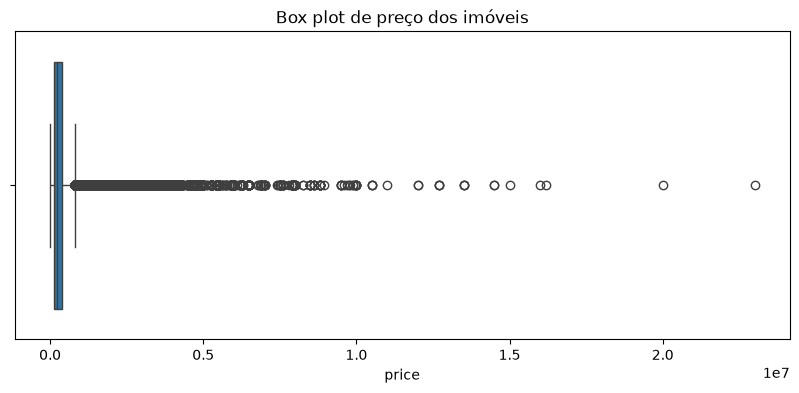

In [54]:
plt.figure(figsize=(10,4))

sns.boxplot(x=df_tratado["price"])

plt.title("Box plot de preço dos imóveis")

plt.show()

# Análise de outliers

O boxplot da variável price evidencia uma distribuição fortemente assimétrica à direita, com grande concentração de imóveis de menor valor e diversos outliers acima do limite superior definido pelo método do IQR. Os valores extremos ultrapassam aproximadamente 650 mil, chegando a mais de 20 milhões. Esses registros podem representar imóveis de alto padrão e não necessariamente erros de cadastro. Como a Regressão Linear é sensível a valores extremos, optou-se por investigar os outliers antes de removê-los e utilizar a transformação logarítmica da variável price, reduzindo a assimetria da distribuição e a influência desses valores sobre o modelo.

In [56]:
#Verificando imóveis com valor = 0 na coluna "price" após o tratamento
(df_tratado["price"] == 0).sum()

np.int64(0)

In [ ]:
# Procurando por valores inconsistentes
df_tratado.nsmallest(
    50,
    "price"
)[["price","m2_useful","room_num","bath_num"]]

,price,m2_useful,room_num,bath_num
11305,1.0,187.0,4.0,3.0
30748,1.0,80.0,3.0,2.0
98021,200.0,80.0,2.0,1.0
98100,220.0,65.0,3.0,1.0
92396,250.0,92.0,4.0,1.0
97991,250.0,99.0,3.0,2.0
98098,250.0,92.0,2.0,1.0
98005,275.0,50.0,2.0,1.0
97958,280.0,92.0,3.0,1.0
97960,280.0,55.0,1.0,1.0


In [58]:
df_tratado.nsmallest(20, "price")

,air_conditioner,balcony,bath_num,built_in_wardrobe,chimney,condition,energetic_certif,floor,garage,garden,...,reduced_mobility,room_num,storage_room,swimming_pool,terrace,number_of_companies_prov,population_prov,companies_prov_vs_national_%,population_prov_vs_national_%,renta_media_prov
11305,0,0,3.0,0,0,promoción de obra nueva,nao informado,nao informado,plaza de garaje incluida en el precio,0,...,0,4.0,0,0,0,96638,1128908,2.90,2.42,19818.0
30748,0,0,2.0,0,0,promoción de obra nueva,nao informado,nao informado,nao informado,0,...,0,3.0,0,0,0,96638,1128908,2.90,2.42,19818.0
98021,0,0,1.0,0,0,segunda mano/buen estado,no indicado,1 planta,nao informado,1,...,0,2.0,0,0,0,11632,174549,0.35,0.37,19818.0
98100,0,0,1.0,1,0,segunda mano/buen estado,inmueble exento,planta 1ª exterior,nao informado,0,...,0,3.0,1,0,0,11632,174549,0.35,0.37,19818.0
92396,0,1,1.0,1,0,segunda mano/buen estado,no indicado,planta 3ª exterior,nao informado,0,...,0,4.0,0,0,1,5689,88600,0.17,0.19,19818.0
97991,0,1,2.0,0,0,segunda mano/buen estado,nao informado,2 plantas,plaza de garaje incluida en el precio,1,...,0,3.0,0,0,0,11632,174549,0.35,0.37,19818.0
98098,0,0,1.0,1,0,segunda mano/buen estado,en trámite,1 planta,nao informado,0,...,0,2.0,0,0,0,11632,174549,0.35,0.37,19818.0
98005,0,0,1.0,0,0,segunda mano/buen estado,no indicado,1 planta,plaza de garaje incluida en el precio,1,...,0,2.0,1,0,1,11632,174549,0.35,0.37,19818.0
97958,0,0,1.0,0,0,segunda mano/buen estado,no indicado,planta 1ª exterior,nao informado,0,...,0,3.0,0,0,0,11632,174549,0.35,0.37,19818.0
97960,0,0,1.0,1,0,segunda mano/buen estado,nao informado,planta 2ª exterior,plaza de garaje incluida en el precio,0,...,0,1.0,1,0,0,11632,174549,0.35,0.37,19818.0


In [59]:
#verificando valores de imoveis abaixo de 1000
(df_tratado["price"] < 1000).sum()

np.int64(1454)

In [ ]:
#Verificando valores de imóveis com preços baixos
df_tratado[df_tratado["price"] < 1000][[
    "price",
    "m2_useful",
    "room_num",
    "bath_num",
    "house_type"
]].head(30)

,price,m2_useful,room_num,bath_num,house_type
3627,750.0,90.0,3.0,1.0,alquiler de piso
3628,750.0,80.0,3.0,1.0,alquiler de piso
3631,700.0,92.0,2.0,1.0,alquiler de piso
3632,550.0,92.0,3.0,1.0,alquiler de piso
3634,650.0,41.0,1.0,1.0,alquiler de piso
3635,800.0,92.0,2.0,2.0,alquiler de piso
3636,650.0,92.0,3.0,2.0,alquiler de piso
3638,840.0,68.0,2.0,2.0,alquiler de dúplex
3639,750.0,92.0,3.0,2.0,alquiler de piso
3640,800.0,210.0,4.0,5.0,alquiler de chalet adosado


In [ ]:
#Verificando variável house_type
df_tratado["house_type"].value_counts()

house_type
piso                                       53963
casa o chalet independiente                13592
casa o chalet                               6868
chalet adosado                              6441
ático                                       3345
casa de pueblo                              3001
dúplex                                      2577
chalet pareado                              2482
finca rústica                               2276
alquiler de piso                            2244
casa rural                                  1564
estudio                                      692
caserón                                      161
alquiler de ático                            101
masía                                        100
alquiler de dúplex                            72
casa terrera                                  69
alquiler de casa o chalet independiente       61
alquiler de chalet adosado                    54
cortijo                                       30
alquiler 

In [62]:
#Removendo registros com house_type iniciando com "alquiler" (aluguel) do dataset tratado
df_tratado_sem_alquiler = df_tratado[
    ~df_tratado["house_type"].str.startswith("alquiler")
]

Durante a etapa de pré-processamento dos dados, foi identificada a presença de registros referentes a imóveis destinados ao aluguel, representados por categorias da variável house_type iniciadas pelo termo "alquiler" (por exemplo, alquiler de piso, alquiler de casa o chalet e alquiler de estudio). Como o objetivo deste projeto é construir um modelo capaz de prever o preço de venda dos imóveis, esses registros foram removidos da base de dados.

A manutenção de imóveis para aluguel no conjunto de dados poderia introduzir inconsistências na modelagem, uma vez que os fatores que determinam o valor de locação são diferentes daqueles que influenciam o preço de venda. Misturar esses dois tipos de mercado faria com que o modelo aprendesse padrões distintos para a mesma variável-alvo, aumentando a variabilidade dos dados e reduzindo a capacidade de generalização.

In [64]:
#conferindo remoção 
df_tratado_sem_alquiler["house_type"].str.startswith("alquiler").sum()

np.int64(0)

In [66]:
#conferindo novamenentte remoção do tipo alquiler da variável house_type
print(
    df_tratado_sem_alquiler["house_type"]
    .str.contains("alquiler", case=False, na=False)
    .sum()
)

0


In [69]:
df_tratado_sem_alquiler["house_type"] = (
    df_tratado_sem_alquiler["house_type"]
    .str.strip()
    .str.lower()
)

In [70]:
df_tratado_sem_alquiler = df_tratado[
    ~df_tratado["house_type"].str.contains("^alquiler", regex=True, na=False)
].copy()

In [71]:
print(
    df_tratado_sem_alquiler["house_type"]
    .str.contains("alquiler", na=False)
    .sum()
)

0


In [73]:
#Verificando se ainda existem dados do tipo alquiler
print(df_tratado_sem_alquiler["house_type"].unique())

<StringArray>
['casa o chalet independiente',                       'ático',
              'casa de pueblo',                        'piso',
                  'casa rural',              'chalet adosado',
               'casa o chalet',                     'caserón',
              'chalet pareado',                      'dúplex',
                     'estudio',               'finca rústica',
                     'palacio',                       'torre',
                    'castillo',                       'masía',
                     'cortijo',                'casa terrera']
Length: 18, dtype: str


In [74]:
#Conferindo o shape do dataset após a remoção dos registros com house_type iniciando com "alquiler"
print(df_tratado_sem_alquiler.shape)
print(df_tratado_sem_alquiler["house_type"].value_counts())

(97205, 30)
house_type
piso                           53963
casa o chalet independiente    13592
casa o chalet                   6868
chalet adosado                  6441
ático                           3345
casa de pueblo                  3001
dúplex                          2577
chalet pareado                  2482
finca rústica                   2276
casa rural                      1564
estudio                          692
caserón                          161
masía                            100
casa terrera                      69
cortijo                           30
palacio                           18
torre                             18
castillo                           8
Name: count, dtype: int64


In [ ]:
#verificando dataset
df_tratado_sem_alquiler.info()

<class 'pandas.DataFrame'>
Index: 97205 entries, 0 to 99999
Data columns (total 30 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   air_conditioner                97205 non-null  str           
 1   balcony                        97205 non-null  str           
 2   bath_num                       97205 non-null  float64       
 3   built_in_wardrobe              97205 non-null  str           
 4   chimney                        97205 non-null  str           
 5   condition                      97205 non-null  str           
 6   energetic_certif               97205 non-null  str           
 7   floor                          97205 non-null  str           
 8   garage                         97205 non-null  str           
 9   garden                         97205 non-null  str           
 10  house_type                     97205 non-null  str           
 11  lift                           

## Remoção de alugueis, mantendo somente imóveis a venda.

Durante a análise exploratória identificou-se que a base de dados continha anúncios de venda e de aluguel, diferenciados pela variável house_type. Como os preços de aluguel e de venda representam mercados distintos e apresentam escalas de valores significativamente diferentes, optou-se por remover todos os anúncios de aluguel antes da etapa de modelagem. Essa filtragem reduziu a heterogeneidade da variável resposta e tornou o conjunto de dados mais consistente para a construção de modelos destinados à predição do preço de venda dos imóveis.

In [76]:
# Conferindo o shape do dataset após a remoção dos registros com house_type iniciando com "alquiler" e verificado ainda registros de preço igual a 1, que não fazem sentido para o modelo de previsão de preços de imóveis.
df_tratado_sem_alquiler[df_tratado_sem_alquiler["price"] == 1]

,air_conditioner,balcony,bath_num,built_in_wardrobe,chimney,condition,energetic_certif,floor,garage,garden,...,reduced_mobility,room_num,storage_room,swimming_pool,terrace,number_of_companies_prov,population_prov,companies_prov_vs_national_%,population_prov_vs_national_%,renta_media_prov
11305,0,0,3.0,0,0,promoción de obra nueva,nao informado,nao informado,plaza de garaje incluida en el precio,0,...,0,4.0,0,0,0,96638,1128908,2.9,2.42,19818.0
30748,0,0,2.0,0,0,promoción de obra nueva,nao informado,nao informado,nao informado,0,...,0,3.0,0,0,0,96638,1128908,2.9,2.42,19818.0


In [77]:
#Removendo variáveis com preço = 1
df_tratado2 = df_tratado_sem_alquiler[df_tratado_sem_alquiler["price"] > 1]

In [78]:
#conferindo remoção anterior
df_tratado2[df_tratado2["price"] == 1]

,air_conditioner,balcony,bath_num,built_in_wardrobe,chimney,condition,energetic_certif,floor,garage,garden,...,reduced_mobility,room_num,storage_room,swimming_pool,terrace,number_of_companies_prov,population_prov,companies_prov_vs_national_%,population_prov_vs_national_%,renta_media_prov


In [82]:
#verificando novamente se existem variáveis com tipo alquiler
df_tratado2["house_type"].str.startswith("alquiler").sum()

df_tratado2[
    df_tratado2["house_type"].str.contains("alquiler", case=False, na=False)
]["house_type"].value_counts()

Series([], Name: count, dtype: int64)

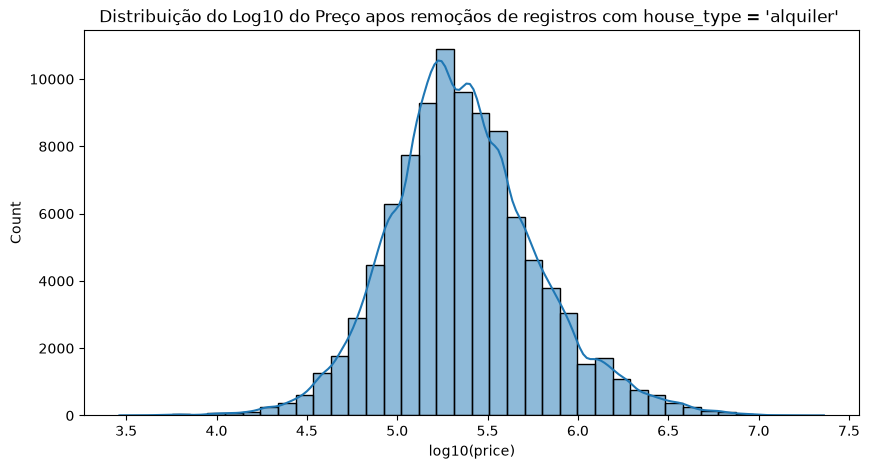

In [83]:
#Gráfico da variavel preço sem alquiler
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.histplot(
    np.log10(df_tratado2["price"]),
    bins=40,
    kde=True
)

plt.title("Distribuição do Log10 do Preço apos remoçãos de registros com house_type = 'alquiler' ")
plt.xlabel("log10(price)")


# Salva o gráfico
plt.savefig(
    "../outputs/figures/histograma_preco_log_sem_alquiler.png",
    dpi=300,
    bbox_inches="tight"
)


### Distribuição da variável `price` após o pré-processamento

A Figura apresenta a distribuição da variável `price` após a remoção dos anúncios de aluguel, eliminação de registros inconsistentes e aplicação da transformação logarítmica na base 10 (`log10(price)`).

Observa-se que a distribuição tornou-se aproximadamente unimodal e significativamente mais simétrica em comparação com a distribuição original. A maior concentração de observações encontra-se entre aproximadamente 5,0 e 5,6 na escala logarítmica, enquanto a curva de densidade acompanha de forma consistente o formato do histograma.

Em relação às análises anteriores, verifica-se o desaparecimento do agrupamento correspondente aos anúncios de aluguel, indicando que o conjunto de dados passou a representar exclusivamente o mercado de venda de imóveis. Além disso, a transformação logarítmica reduziu substancialmente a influência dos imóveis de maior valor, diminuindo a assimetria da variável resposta e tornando sua distribuição mais homogênea.

Apesar da permanência de uma discreta cauda à direita, característica comum em bases de dados imobiliárias, a distribuição obtida apresenta comportamento muito mais adequado para a etapa de modelagem preditiva, reduzindo o impacto dos valores extremos sem eliminar observações representativas do mercado.

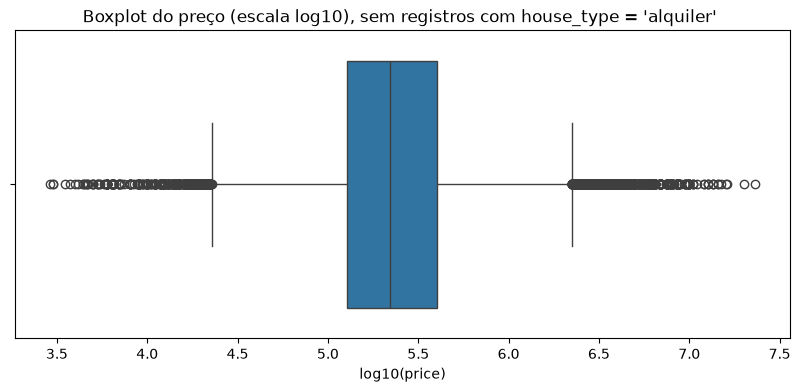

In [84]:
# Gráfico boxplot da variável preço sem alquiler
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,4))

sns.boxplot(x=np.log10(df_tratado2["price"]))

plt.title("Boxplot do preço (escala log10), sem registros com house_type = 'alquiler' ")
plt.xlabel("log10(price)")

# Salva o gráfico
plt.savefig(
    "../outputs/figures/boxplot_preco_log_sem_alquiler.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Boxplot da variável `price` após transformação logarítmica

A Figura apresenta o boxplot da variável `price` após a aplicação da transformação logarítmica na base 10 (`log10(price)`). Observa-se uma distribuição significativamente mais equilibrada quando comparada à escala original, evidenciando a redução da influência dos imóveis de maior valor sobre a distribuição dos dados.

A mediana encontra-se aproximadamente centralizada no intervalo interquartil (IQR), indicando maior simetria da distribuição após a transformação. Os limites dos bigodes abrangem a maior parte das observações, enquanto os pontos localizados além desses limites representam imóveis classificados como outliers segundo o critério de 1,5 vezes o IQR.

Embora ainda exista um número considerável de valores extremos, esse comportamento é esperado em bases de dados do mercado imobiliário, devido à coexistência de imóveis de diferentes padrões e faixas de preço. Após a transformação logarítmica, esses outliers passaram a exercer influência significativamente menor sobre a distribuição da variável resposta.

Em conjunto com o histograma da variável transformada, o boxplot confirma que a aplicação da transformação logarítmica tornou a distribuição dos preços mais homogênea e mais adequada para a etapa de modelagem preditiva.

In [85]:
#Comparação entre assimetrias do preço original e do preço transformado (log10):
print("Assimetria do preço original:")
print(df_tratado["price"].skew())

print("\nAssimetria do preço transformado:")
print(np.log10(df_tratado2["price"]).skew())   # ou price_log.skew()

Assimetria do preço original:
7.450633710246744

Assimetria do preço transformado:
0.3187142826859461


A variável-alvo `price` apresentou coeficiente de assimetria igual a 7,45, indicando forte assimetria positiva. Esse resultado demonstra que a maior parte dos imóveis concentra-se em faixas de preço inferiores, enquanto um número reduzido de imóveis de alto valor gera uma longa cauda na distribuição. Essa característica motivou a aplicação da transformação logarítmica da variável resposta (`price_log`), com o objetivo de reduzir a influência dos valores extremos e melhorar o desempenho dos modelos de regressão.

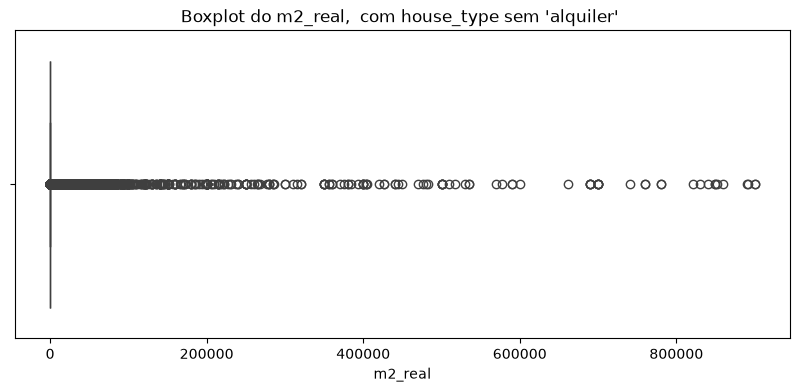

In [86]:
#Boxplot do m2_real,  com house_type sem 'alquiler

plt.figure(figsize=(10,4))

sns.boxplot(x=df_tratado2["m2_real"])

plt.title("Boxplot do m2_real,  com house_type sem 'alquiler' ")
plt.xlabel("m2_real")

# Salva o gráfico
plt.savefig(
    "../outputs/figures/boxplot_m2_real.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

## Análise do gráfico
O boxplot da variável m2_real evidencia que a distribuição da área construída também é fortemente assimétrica à direita, com uma grande quantidade de imóveis concentrados em áreas pequenas e médias e diversos valores extremamente elevados.

Análise do gráfico
A caixa do boxplot está comprimida próxima ao início da escala, indicando que a maior parte dos imóveis possui áreas relativamente pequenas.
O bigode superior termina muito antes do valor máximo observado, e a partir dele aparecem centenas de pontos isolados, classificados como outliers pelo método do IQR.
Existem imóveis com áreas superiores a 900.000 m², valor extremamente elevado para uma residência e que merece investigação.
Identificação dos outliers

Visualmente, os outliers começam aproximadamente entre 5.000 e 10.000 m² (o valor exato deve ser calculado pelo IQR). A partir desse ponto há imóveis com áreas cada vez maiores, chegando a aproximadamente:

100.000 m²
300.000 m²
500.000 m²
mais de 900.000 m²

Esses valores são muito superiores à área típica de imóveis residenciais.

Esses outliers podem ser erros?

Nem todos.

Alguns podem representar:

fazendas;
terrenos;
condomínios;
imóveis comerciais.

Entretanto, áreas como 300.000, 500.000 ou 900.000 m² são bastante incomuns para um dataset de imóveis residenciais e podem indicar:

erro de digitação;
unidade de medida incorreta;
área do terreno cadastrada no lugar da área construída;
registros inconsistentes.

Vale a pena investigar esses casos antes da modelagem.

In [87]:
df_tratado2.nlargest(
    20,
    "m2_real"
)[["m2_real", "m2_useful", "price", "house_type"]]

,m2_real,m2_useful,price,house_type
31098,900000,625.0,6000000.0,casa o chalet
89389,900000,92.0,3000000.0,casa o chalet independiente
32552,891800,1648.0,3182000.0,finca rústica
32468,890000,1613.0,3450000.0,casa rural
32415,860000,75.0,1300000.0,finca rústica
29042,851360,600.0,5500000.0,casa o chalet
12237,850000,92.0,2900000.0,finca rústica
35601,850000,355.0,350000.0,masía
31213,840000,780.0,840000.0,casa o chalet independiente
11862,830000,92.0,3950000.0,casa o chalet


In [88]:
# variável m2_useful apresentou aproximadamente 47% de valores ausentes na base original. Para permitir a utilização dessa informação durante a modelagem, os valores faltantes foram imputados pela mediana da variável, por ser uma medida robusta à presença de valores extremos. Entretanto, reconhece-se que a elevada proporção de dados ausentes pode reduzir a variabilidade dessa característica e limitar seu poder explicativo nos modelos preditivos.
df_tratado2.loc[
    df_tratado2["m2_useful"] > df_tratado2["m2_real"],
    ["m2_real", "m2_useful", "price", "house_type"]
].sample(20, random_state=42)

,m2_real,m2_useful,price,house_type
685,80,92.0,161000.0,piso
64633,100,208.0,160000.0,casa de pueblo
52204,80,92.0,248000.0,piso
9931,65,70.0,116000.0,chalet pareado
40434,50,92.0,134000.0,piso
85170,81,92.0,840000.0,piso
39683,170,400.0,570000.0,casa o chalet independiente
82725,60,92.0,305000.0,piso
46339,81,92.0,200000.0,piso
77187,82,92.0,229000.0,piso


In [ ]:
#Procurando registros com m2_useful igual a 92 no dataset atual
(df_tratado2["m2_useful"] == 92).sum()

np.int64(46509)

In [90]:
#Pesquisando registros com m2_useful igual a 92 no dataset original
(df["m2_useful"] == 92).sum()

np.int64(0)

In [91]:
#Pesquisando registros com m2_useful nulo no dataset original
df["m2_useful"].isna().sum()

np.int64(47156)

 ## Importante:
 
 variável m2_useful apresentou aproximadamente 47% de valores ausentes na base original. Para permitir a utilização dessa informação durante a modelagem, os valores faltantes foram imputados pela mediana da variável, por ser uma medida robusta à presença de valores extremos. Entretanto, reconhece-se que a elevada proporção de dados ausentes pode reduzir a variabilidade dessa característica e limitar seu poder explicativo nos modelos preditivos.

In [93]:
#Pesquisando registros com erros em m2_useful  no dataset tratado
df_tratado2.sort_values("m2_real", ascending=False)[
    ["m2_real", "price", "room_num", "bath_num", "house_type"]
].head(20)

,m2_real,price,room_num,bath_num,house_type
31098,900000,6000000.0,13.0,5.0,casa o chalet
89389,900000,3000000.0,9.0,8.0,casa o chalet independiente
32552,891800,3182000.0,3.0,2.0,finca rústica
32468,890000,3450000.0,6.0,2.0,casa rural
32415,860000,1300000.0,3.0,2.0,finca rústica
29042,851360,5500000.0,3.0,2.0,casa o chalet
35601,850000,350000.0,6.0,2.0,masía
12237,850000,2900000.0,6.0,3.0,finca rústica
31213,840000,840000.0,9.0,7.0,casa o chalet independiente
11862,830000,3950000.0,16.0,2.0,casa o chalet


A tabela acima mostra que  nem todos esses registros são erros. Muitos parecem representar propriedades rurais ou imóveis de luxo, o que justifica áreas muito grandes.

Análise dos maiores valores
Área (m²)	Tipo de imóvel	Avaliação
900.000	Casa/Chalé	Possível propriedade de luxo ou fazenda
900.000	Casa/Chalé	Possível
891.800	Finca rústica	Coerente
890.000	Casa rural	Coerente
860.000	Finca rústica	Coerente
851.360	Casa/Chalé	Pode ser propriedade rural
850.000	Finca rústica	Coerente
850.000	Masía	Coerente
840.000	Casa independente	Possível
830.000	Casa/Chalé	Possível
820.912	Finca rústica	Coerente
781.000	Finca rústica	Coerente
780.000	Castelo	Totalmente coerente
760.000	Masía	Coerente
741.425	Casa rural	Coerente....

A inspeção dos maiores valores da variável m2_real mostrou que os principais outliers correspondem, em sua maioria, a imóveis classificados como finca rústica, casa rural, masía e castillo. Esses tipos de imóveis normalmente abrangem grandes extensões de terreno, justificando áreas superiores a 700.000 m². Dessa forma, conclui-se que esses valores representam características reais do mercado imobiliário espanhol e não necessariamente erros de cadastro. Por esse motivo, optou-se por manter esses registros no conjunto de dados, uma vez que sua remoção poderia eliminar informações relevantes sobre imóveis de grande porte. Contudo, reconhece-se que esses valores extremos podem influenciar modelos sensíveis, como a Regressão Linear, sendo considerada a utilização de transformações logarítmicas e a avaliação de modelos mais robustos durante a etapa de modelagem.

Observação: É importante verificar a documentação do dataset para confirmar o significado de m2_real. Em muitos conjuntos de dados imobiliários, ela representa a área do imóvel (construída), mas em alguns casos pode representar a área total do terreno. Se for área do terreno, valores como 900.000 m² (90 hectares) são perfeitamente plausíveis para uma fazenda ou propriedade rural.


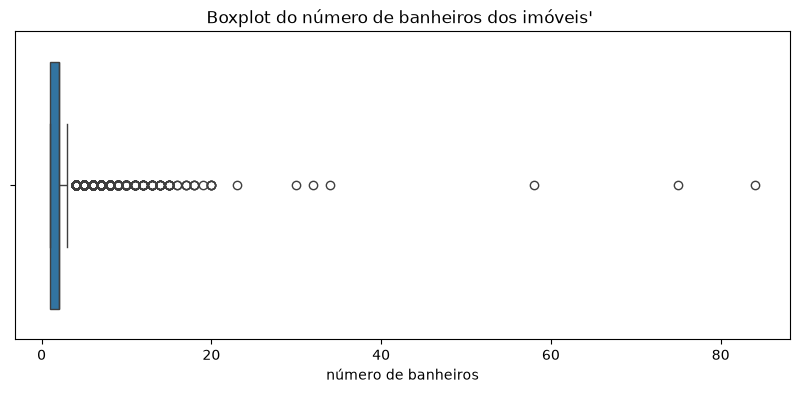

In [96]:
plt.figure(figsize=(10,4))

sns.boxplot(x=df_tratado2["bath_num"])
plt.title("Boxplot do número de banheiros dos imóveis' ")
plt.xlabel("número de banheiros")

plt.show()

### Boxplot da variável `bath_num`

A Figura apresenta o boxplot da variável `bath_num`, correspondente ao número de banheiros dos imóveis. Observa-se que a maior parte das propriedades possui entre um e três banheiros, resultando em uma distribuição concentrada nas menores faixas da variável.

O boxplot identifica diversos valores classificados como outliers, principalmente acima de cinco banheiros. Entretanto, essa característica é esperada em variáveis discretas e assimétricas, nas quais o critério de 1,5 vezes o intervalo interquartil (IQR) tende a identificar como valores extremos observações relativamente incomuns, mas não necessariamente incorretas.

Durante a inspeção dos dados foram identificados alguns registros com quantidades excepcionalmente elevadas de banheiros (superiores a 30), associados, em alguns casos, a inconsistências entre o número de banheiros e a área útil do imóvel. Esses registros foram analisados individualmente durante a etapa de pré-processamento.

De modo geral, o gráfico confirma que a variável apresenta forte assimetria positiva, com predominância de imóveis contendo poucos banheiros e uma pequena quantidade de propriedades com valores muito superiores à média. Essa característica é compatível com a natureza do mercado imobiliário e foi considerada durante a construção dos modelos preditivos.

Impacto na modelagem

Como a variável bath_num apresentou uma correlação moderada com o preço (≈ 0,54), ela é uma variável importante para a previsão. Portanto, a remoção de outliers deve ser feita com cautela para evitar a perda de informações relevantes sobre imóveis de alto padrã

In [97]:
#procurando valores de número de banheiros discrepantes
df_tratado2[df_tratado2["bath_num"] > 10][
    ["bath_num", "room_num", "m2_real", "price", "house_type"]
].sort_values("bath_num", ascending=False)

,bath_num,room_num,m2_real,price,house_type
15521,84.0,84.0,3,23000000.0,palacio
91054,75.0,73.0,3095,1200000.0,casa o chalet independiente
87019,58.0,58.0,7763,4000000.0,caserón
2791,34.0,30.0,1900,1500000.0,caserón
31530,32.0,32.0,1458,2800000.0,casa o chalet independiente
...,...,...,...,...,...
10744,11.0,10.0,13200,3300000.0,casa o chalet independiente
31716,11.0,11.0,171845,2650000.0,casa o chalet
60129,11.0,16.0,1100,300000.0,casa rural
45372,11.0,17.0,594,860000.0,casa o chalet independiente


In [99]:
#Procurando registros inconsistentes de número de banheiros
df_tratado2[
    (df_tratado2["room_num"] > 30) &
    (df_tratado2["m2_real"] < 50)
]

,air_conditioner,balcony,bath_num,built_in_wardrobe,chimney,condition,energetic_certif,floor,garage,garden,...,reduced_mobility,room_num,storage_room,swimming_pool,terrace,number_of_companies_prov,population_prov,companies_prov_vs_national_%,population_prov_vs_national_%,renta_media_prov
15521,1,1,84.0,1,1,segunda mano/buen estado,en trámite,3 plantas,plaza de garaje incluida en el precio,1,...,0,84.0,1,1,1,96638,1128908,2.9,2.42,19818.0


In [100]:
#Removendo registro inconsistente 
df_tratado2 = df_tratado2.drop(index=[15496])

 A investigação dos outliers da variável bath_num mostrou que nem todos representam erros de cadastro. Diversos imóveis com elevado número de banheiros pertencem às categorias casarão, palácio e propriedades rurais, apresentando também grande área construída e elevado valor de mercado, o que justifica esses valores extremos. Entretanto, foram identificados registros claramente inconsistentes, como um imóvel com apenas 3 m², 84 quartos, 84 banheiros e preço de 23 milhões, indicando provável erro de cadastro. 
Apenas esses registros inconsistentes foram removidos, enquanto os demais outliers foram mantidos por representarem imóveis reais de grande porte. Essa abordagem preserva informações relevantes do mercado imobiliário sem introduzir distorções desnecessárias no modelo preditivo.

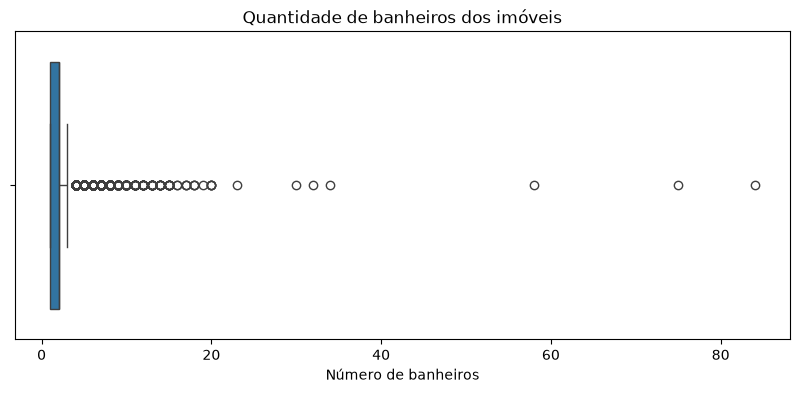

In [101]:
#Gráfico da quantidade de banheiros dos imóveis
plt.figure(figsize=(10,4))

sns.boxplot(x=df_tratado2["bath_num"])
plt.title("Quantidade de banheiros dos imóveis")
plt.xlabel("Número de banheiros")

# Salva o gráfico
plt.savefig(
    "../outputs/figures/boxplot_quantidade_banheiros.png",
    dpi=300,
    bbox_inches="tight"
)
#plt.ylabel("Preço (log)")

plt.show()

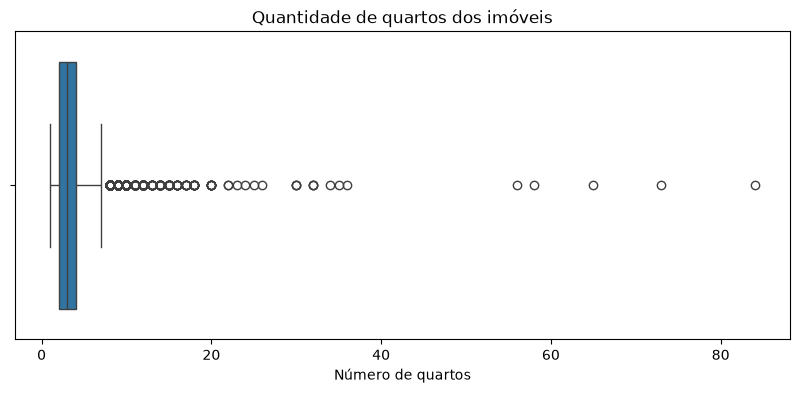

In [102]:
#Gráfico da quantidade de quartos dos imóveis
plt.figure(figsize=(10,4))

sns.boxplot(x=df_tratado2["room_num"])
plt.title("Quantidade de quartos dos imóveis")
plt.xlabel("Número de quartos")



# Salva o gráfico
plt.savefig(
    "../outputs/figures/boxplot_quantidade_quartos.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()



# Análise do gráfico de quartos

O boxplot da variável room_num evidencia que a maior parte dos imóveis possui entre 2 e 5 quartos, faixa representada pela região central da caixa (intervalo interquartil). A mediana encontra-se próxima de 3 ou 4 quartos, indicando que esse é o padrão predominante no conjunto de dados.

Observa-se uma quantidade considerável de outliers superiores, principalmente a partir de aproximadamente 8 quartos, estendendo-se até imóveis com mais de 70 quartos. Esses registros representam propriedades muito diferentes do padrão da base, como hotéis, palácios, casarões, castelos ou grandes propriedades rurais, e não refletem o perfil da maioria dos imóveis residenciais.

A presença desses valores extremos aumenta significativamente a dispersão da variável e pode influenciar modelos sensíveis, como a Regressão Linear, distorcendo seus coeficientes. Entretanto, esses registros podem representar imóveis reais e de alto padrão, não sendo necessariamente erros de cadastro.

Por esse motivo, a decisão de remover ou manter esses outliers deve considerar a natureza do problema. Caso o objetivo seja construir um modelo voltado ao mercado residencial comum, a remoção ou limitação desses valores extremos pode melhorar a capacidade de generalização do modelo. Por outro lado, se o objetivo for representar todo o mercado imobiliário, incluindo imóveis de luxo, esses registros devem ser preservados, podendo-se optar por técnicas menos sensíveis a outliers, como Random Forest Regressor, ou pela aplicação de transformações logarítmicas na variável alvo.

De forma geral, o gráfico confirma que a distribuição da variável room_num é fortemente assimétrica à direita, com predominância de imóveis contendo poucos quartos e uma pequena quantidade de propriedades extremamente grandes, caracterizando a existência de valores discrepantes (outliers) que devem ser considerados durante a etapa de preparação dos dados.

In [103]:
#Removendo variáveis
colunas_remover = [
    "companies_prov_vs_national_%",
    "population_prov_vs_national_%"]
    #"population_prov"]

df_tratado2.drop(columns=colunas_remover, inplace=True)

## Removidas as variáveis:


- companies_prov_vs_national_%
- population_prov_vs_national_%

Entre elas, a correlação é 1,00.

Isso significa que elas são praticamente redundantes: carregam a mesma informação ou informações muito próximas. Em modelos lineares, isso pode causar multicolinearidade.


## Fase 3: 
Feature Engineering (Coluna Calculada) Você pode conceber e calcular, de forma opcional, pelo menos uma nova coluna numérica com base em operações matemáticas ou lógicas sobre variáveis pré-existentes, garantindo o tratamento prévio de nulos para evitar divisões inválidas ou valores inconsistentes: Se escolheu a Opção A (Imóveis), algumas sugestões de cálculo de novas colunas numéricas: idade_imovel: idade do imóvel no momento da venda, calculada a partir do ano de venda (extraído da coluna date) menos yr_built. preco_por_m2: price dividido pela área construída (sqft_living), útil para comparar imóveis de tamanhos diferentes. Atenção: por derivar de price, essa coluna serve para leitura/EDA, mas não deve ser usada como variável preditora da própria variável-alvo price (risco de vazamento de dados). foi_reformado: variável derivada de yr_renovated que indica se o imóvel foi reformado. 
Se escolheu a Opção B (dataset livre): calcule uma coluna equivalente ao seu contexto, desde que ela resulte de operações matemáticas ou lógicas sobre variáveis já existentes no seu dataset. Note: essas são sugestões; você pode explorar outras combinações de colunas para atingir esse objetivo, desde que a lógica seja explicada e justificada no notebook (ou no seu vídeo).

## Opção 1 – Preço por metro quadrado (recomendada para EDA)

Atenção: Como essa variável utiliza price (a variável alvo), ela não deve ser usada para prever price, pois causaria vazamento de dados (data leakage). Ela é excelente para análise exploratória.

In [105]:
# Criação da varíavel price_m2
df_tratado2 = df_tratado[df_tratado["m2_real"] > 0].copy()

df_tratado2["price_m2"] = (
    df_tratado2["price"] / df_tratado2["m2_real"]
)

In [106]:
#Verificar o resultado do tratamento da variável price_m2  
df_tratado2[["price", "m2_real", "price_m2"]].head()

,price,m2_real,price_m2
0,310000.0,1000,310.000000
1,139000.0,86,1616.279070
2,480000.0,3000,160.000000
3,150000.0,86,1744.186047
4,90000.0,76,1184.210526


## Justificativa:

Foi criada a variável preco_por_m2, que representa o valor médio pago por metro quadrado do imóvel. Essa variável facilita a comparação entre imóveis de diferentes tamanhos e é útil para análises exploratórias, embora não deva ser utilizada como variável preditora da própria variável price, evitando vazamento de dados.

## Opção 2 – Banheiros por quarto 

In [107]:
#Criaço da variável banheiros_por_quarto, que representa a proporção de banheiros por quarto em cada imóvel. Para evitar divisão por zero, substituímos os valores zero na coluna "room_num" por NaN antes de realizar a divisão.
df_tratado2["bath_per_room"] = (
    df_tratado2["bath_num"] /
    df_tratado2["room_num"].replace(0, np.nan)
)

In [108]:
#verificando o resultado do tratamento da variável banheiros_por_quarto
df_tratado2[["bath_num","room_num","bath_per_room"]].head()

,bath_num,room_num,bath_per_room
0,2.0,4.0,0.500000
1,2.0,3.0,0.666667
2,3.0,4.0,0.750000
3,1.0,4.0,0.250000
4,1.0,2.0,0.500000


## Justificativa:

Essa variável representa a proporção de banheiros por quarto. Imóveis com maior disponibilidade de banheiros tendem a apresentar maior conforto e podem possuir maior valor de mercado.

## Opção 3 – Área útil (%)


In [109]:
df_tratado2["perc_area_util"] = (
    df_tratado2["m2_useful"] /
    df_tratado2["m2_real"].replace(0, np.nan)
) * 100

In [110]:
#verificando o resultado do tratamento da variável percentual area util
df_tratado2[["m2_useful","m2_real","perc_area_util"]].head()

,m2_useful,m2_real,perc_area_util
0,172.0,1000,17.200000
1,92.0,86,106.976744
2,92.0,3000,3.066667
3,92.0,86,106.976744
4,74.0,76,97.368421


## Opção 4 - Quartos por m²

In [111]:
# Quartos por metro quadrado
df_tratado2["rooms_per_m2"] = (
    df_tratado2["room_num"] / df_tratado2["m2_real"]
)

In [112]:
#verificando o resultado do tratamento da variável quartos por m2
df_tratado2[["m2_useful","m2_real","rooms_per_m2"]].head()

,m2_useful,m2_real,rooms_per_m2
0,172.0,1000,0.004000
1,92.0,86,0.034884
2,92.0,3000,0.001333
3,92.0,86,0.046512
4,74.0,76,0.026316


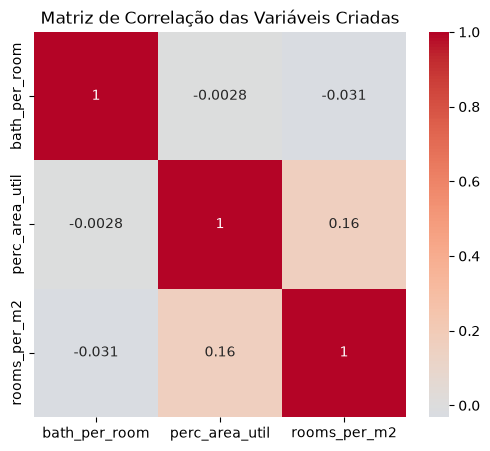

In [114]:
#Criando matriz de correlação de Pearson entra as variáveis recem criadas

# Variáveis da matriz
colunas_corr = [
    "bath_per_room",
    "perc_area_util",
    "rooms_per_m2"
]

# Cria a figura
plt.figure(figsize=(6,5))

sns.heatmap(
    df_tratado2[colunas_corr].corr(),
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Matriz de Correlação das Variáveis Criadas")

# Salva a figura
plt.savefig(
    "../outputs/figures/matriz_correlacao_variaveis_criadas.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Correlação entre as variáveis criadas

A matriz de correlação de Pearson acima foi utilizada para avaliar a relação linear entre as novas variáveis geradas durante a etapa de engenharia de atributos (`bath_per_room`, `perc_area_util` e `rooms_per_m2`).

Observa-se que todas as correlações apresentaram magnitude baixa. A variável `bath_per_room` apresentou correlação praticamente nula com `perc_area_util` (r = -0,028) e `rooms_per_m2` (r = -0,031), indicando que representa uma informação independente das demais características derivadas.

A maior correlação observada foi entre `perc_area_util` e `rooms_per_m2` (r = 0,16), valor considerado fraco segundo a literatura, não caracterizando problemas de multicolinearidade.

Esses resultados indicam que as variáveis criadas acrescentam informações complementares ao conjunto de dados e podem ser utilizadas como atributos preditores, uma vez que não apresentam redundância significativa entre si.

## Justificativa:

Foi realizada uma etapa de engenharia de atributos com o objetivo de criar variáveis mais representativas. A variável preco_por_m2 foi calculada dividindo o preço do imóvel pela área construída (m2_real), permitindo comparar imóveis de diferentes dimensões. Como essa variável é derivada diretamente do preço, ela foi utilizada apenas na análise exploratória e não será empregada como variável explicativa na modelagem para evitar vazamento de dados (data leakage). Além disso, foi criada a variável banheiros_por_quarto, obtida pela razão entre o número de banheiros e o número de quartos, representando um indicador de conforto do imóvel que poderá ser utilizado na etapa de modelagem.

## Fase 4: 

Preparação para Modelagem Codificação (Encoding): caso utilize variáveis qualitativas (categóricas) como variáveis explicativas/preditoras, trate-as aplicando codificadores apropriados (como Label Encoding ou One-Hot Encoding). No dataset de imóveis, colunas como waterfront, view e condition já são numéricas ordinais e podem ser usadas diretamente; já uma variável nominal como zipcode, costuma exigir uma estratégia mais cuidadosa (por exemplo, agrupar em faixas antes de aplicar One-Hot Encoding, veja a estratégia mais complexa usada no repositório usado como referência). Multicolinearidade: antes de treinar o modelo, avalie a multicolinearidade entre as variáveis explicativas usando a matriz de correlação e/ou o VIF (Fator de Inflação da Variância), técnicas abordadas no repositório de referência e nas aulas. Remova ou combine variáveis altamente correlacionadas, documentando sua decisão. Divisão Amostral (Split): Separe as variáveis explicativas/preditoras (X) da sua variável-alvo (y) e fragmente o conjunto em dados de Treino e dados de Teste (por convenção, use proporções como 80/20, ou 75/25). Escalonamento Seguro: aplique o StandardScaler às variáveis, demonstrando os ajustes corretos (fit_transform no treino e transform no teste).

In [115]:
df_tratado2["price_log"] = np.log1p(df_tratado2["price"])
y = df_tratado2["price_log"]      # para Regressão Linear e KNN
# ou
# y = df_tratado2["price"]         # para Random Forest

In [116]:
X = df_tratado2.drop(
    columns=[
        "price",
        "price_log",
        "price_m2"
    ],
    errors="ignore"
)

In [117]:
X.select_dtypes(include=["object","string"]).columns

Index(['air_conditioner', 'balcony', 'built_in_wardrobe', 'chimney',
       'condition', 'energetic_certif', 'floor', 'garage', 'garden',
       'house_type', 'lift', 'loc_city', 'loc_district', 'loc_full',
       'loc_zone', 'reduced_mobility', 'storage_room', 'swimming_pool',
       'terrace'],
      dtype='str')

In [118]:
X = pd.get_dummies(
    X,
    columns=[
        "house_type",
        "condition",
        "energetic_certif"
    ],
    drop_first=True,
    dtype="int8"
)

In [119]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,10))

sns.heatmap(
    X.corr(),
    cmap="coolwarm",
    center=0
)

plt.title("Matriz de Correlação")
plt.show()

ValueError: could not convert string to float: '2 plantas'

<Figure size 1400x1000 with 0 Axes>

In [120]:
print(X.dtypes.value_counts())

int8              35
str               16
float64            9
int64              3
datetime64[us]     1
Name: count, dtype: int64


In [121]:
print(X.dtypes.value_counts())

int8              35
str               16
float64            9
int64              3
datetime64[us]     1
Name: count, dtype: int64


In [122]:
X.info()

<class 'pandas.DataFrame'>
Index: 99816 entries, 0 to 99999
Data columns (total 64 columns):
 #   Column                                              Non-Null Count  Dtype         
---  ------                                              --------------  -----         
 0   air_conditioner                                     99816 non-null  str           
 1   balcony                                             99816 non-null  str           
 2   bath_num                                            99816 non-null  float64       
 3   built_in_wardrobe                                   99816 non-null  str           
 4   chimney                                             99816 non-null  str           
 5   floor                                               99816 non-null  str           
 6   garage                                              99816 non-null  str           
 7   garden                                              99816 non-null  str           
 8   lift                  

In [124]:
# 1. Limpar
df_tratado["house_type"] = (
    df_tratado["house_type"]
    .str.strip()
    .str.lower()
)

# 2. Remover aluguéis
df_tratado2 = df_tratado[
    ~df_tratado["house_type"].str.startswith("alquiler", na=False)
].copy()

# 3. Conferir
print(df_tratado2["house_type"].unique())

# 4. Agora sim criar as dummies
df_modelo = pd.get_dummies(
    df_tratado2,
    columns=["house_type", "condition", "energetic_certif"],
    drop_first=True,
    dtype="int8"
)

<StringArray>
['casa o chalet independiente',                       'ático',
              'casa de pueblo',                        'piso',
                  'casa rural',              'chalet adosado',
               'casa o chalet',                     'caserón',
              'chalet pareado',                      'dúplex',
                     'estudio',               'finca rústica',
                     'palacio',                       'torre',
                    'castillo',                       'masía',
                     'cortijo',                'casa terrera']
Length: 18, dtype: str


In [125]:
print("df_tratado:", df_tratado.shape)
print("df_tratado2:", df_tratado2.shape)

df_tratado: (99816, 30)
df_tratado2: (97205, 30)


In [126]:
df_tratado2["house_type"].str.contains("alquiler", na=False).sum()

np.int64(0)

In [127]:
print(df_modelo.shape)
print(df_modelo.filter(like="house_type_alquiler").columns.tolist())

(97205, 50)
[]


In [128]:
df_modelo = pd.get_dummies(
    df_tratado2,
    columns=["house_type", "condition", "energetic_certif", "garage", "floor"],
    drop_first=True,
    dtype="int8"
)

In [129]:
df_modelo.filter(like="house_type_alquiler").columns

Index([], dtype='str')

In [130]:
print(df_tratado2.shape)
print(df_modelo.shape)
print(X.shape)

(97205, 30)
(97205, 276)
(99816, 64)


In [131]:
# variável alvo
y = np.log1p(df_modelo["price"])

# variáveis explicativas
X = df_modelo.drop(columns=["price"])

In [132]:
print(X.shape)

(97205, 275)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

In [134]:
X = df_tratado2.drop(columns=["price", "price_log"], errors="ignore")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Matriz de correlação
corr = X.corr()

plt.figure(figsize=(18, 15))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.2,
    cbar_kws={"shrink": 0.8}
)

plt.title("Matriz de Correlação das Variáveis Explicativas", fontsize=16)
plt.tight_layout()

plt.savefig("outputs/figures/matriz_correlacao.png", dpi=300)

plt.show()

In [135]:
# Mostra todas as colunas que ainda não são numéricas
nao_numericas = X.select_dtypes(exclude=["number"])

print(nao_numericas.columns)
print()
print(nao_numericas.dtypes)

Index(['air_conditioner', 'balcony', 'built_in_wardrobe', 'chimney',
       'condition', 'energetic_certif', 'floor', 'garage', 'garden',
       'house_type', 'lift', 'loc_city', 'loc_district', 'loc_full',
       'loc_zone', 'obtention_date', 'reduced_mobility', 'storage_room',
       'swimming_pool', 'terrace'],
      dtype='str')

air_conditioner                 str
balcony                         str
built_in_wardrobe               str
chimney                         str
condition                       str
energetic_certif                str
floor                           str
garage                          str
garden                          str
house_type                      str
lift                            str
loc_city                        str
loc_district                    str
loc_full                        str
loc_zone                        str
obtention_date       datetime64[us]
reduced_mobility                str
storage_room                    str
swimming_pool   

In [136]:
booleanas = [
    "air_conditioner",
    "balcony",
    "built_in_wardrobe",
    "chimney",
    "garden",
    "lift",
    "reduced_mobility",
    "storage_room",
    "swimming_pool",
    "terrace"
]

for col in booleanas:
    print(f"\n{col}")
    print(df_modelo[col].value_counts(dropna=False))


air_conditioner
air_conditioner
0    74352
1    22853
Name: count, dtype: int64

balcony
balcony
0    79571
1    17634
Name: count, dtype: int64

built_in_wardrobe
built_in_wardrobe
0    56065
1    41140
Name: count, dtype: int64

chimney
chimney
0    93533
1     3672
Name: count, dtype: int64

garden
garden
0    69652
1    27553
Name: count, dtype: int64

lift
lift
nao informado    40812
1                23156
1.0              13477
0                13326
0.0               6434
Name: count, dtype: int64

reduced_mobility
reduced_mobility
0    89460
1     7745
Name: count, dtype: int64

storage_room
storage_room
0    56684
1    40521
Name: count, dtype: int64

swimming_pool
swimming_pool
0    78884
1    18321
Name: count, dtype: int64

terrace
terrace
0    50252
1    46953
Name: count, dtype: int64


In [137]:
booleanas = [
    "air_conditioner",
    "balcony",
    "built_in_wardrobe",
    "chimney",
    "garden",
    "reduced_mobility",
    "storage_room",
    "swimming_pool",
    "terrace"
]

for col in booleanas:
    df_modelo[col] = df_modelo[col].astype("int8")

In [138]:
df_modelo["lift"] = (
    df_modelo["lift"]
    .replace({
        "1": 1,
        "1.0": 1,
        "0": 0,
        "0.0": 0,
        "nao informado": 0
    })
    .astype("int8")
)

In [139]:
df_modelo["lift"] = (
    df_modelo["lift"]
    .replace({
        "1": 1,
        "1.0": 1,
        "0": 0,
        "0.0": 0,
        "nao informado": 0
    })
    .astype("int8")
)

In [140]:
print(df_modelo["lift"].value_counts())
print(df_modelo["lift"].dtype)

lift
0    60572
1    36633
Name: count, dtype: int64
int8


In [141]:
df_modelo = df_modelo.drop(
    columns=[
        "loc_city",
        "loc_district",
        "loc_full",
        "loc_zone",
        "obtention_date",        
        "population_prov_vs_national_%",
        "companies_prov_vs_national_%" 
    ],
    errors="ignore"
)

In [142]:
X = df_modelo.drop(columns=["price", "price_log"], errors="ignore")

In [143]:
print(X.select_dtypes(exclude="number").columns)

Index([], dtype='str')


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Matriz de correlação
corr = X.corr()

plt.figure(figsize=(18, 15))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.2,
    cbar_kws={"shrink": 0.8}
)

plt.title("Matriz de Correlação das Variáveis Explicativas", fontsize=16)
plt.tight_layout()

plt.savefig("outputs/figures/matriz_correlacao.png", dpi=300)

plt.show()

In [144]:
corr = X.corr().abs()

corr_pairs = (
    corr.where(~np.eye(corr.shape[0], dtype=bool))
        .stack()
        .sort_values(ascending=False)
)

corr_pairs.head(20)

number_of_companies_prov                       population_prov                                  0.995412
population_prov                                number_of_companies_prov                         0.995412
bath_num                                       room_num                                         0.666851
room_num                                       bath_num                                         0.666851
condition_segunda mano/buen estado             condition_segunda mano/para reformar             0.571300
condition_segunda mano/para reformar           condition_segunda mano/buen estado               0.571300
population_prov                                renta_media_prov                                 0.535082
renta_media_prov                               population_prov                                  0.535082
lift                                           house_type_piso                                  0.510585
house_type_piso                                lift    

In [145]:
corr = X.corr().abs()

alta_corr = (
    corr.where(~np.eye(corr.shape[0], dtype=bool))
        .stack()
        .reset_index()
)

alta_corr.columns = ["Variável 1", "Variável 2", "Correlação"]

alta_corr = alta_corr[
    alta_corr["Correlação"] >= 0.80
].sort_values("Correlação", ascending=False)

alta_corr

,Variável 1,Variável 2,Correlação
3767,number_of_companies_prov,population_prov,0.995412
4034,population_prov,number_of_companies_prov,0.995412


In [147]:
X = X.drop(
    columns=[
        "population_prov_vs_national_%",
        "companies_prov_vs_national_%",
        "number_of_companies_prov "
    ],
    errors="ignore"
)

In [228]:
# Variáveis explicativas
X = X.drop(
    columns=[
        "population_prov_vs_national_%",
        "companies_prov_vs_national_%",
        "number_of_companies_prov",
    ],
    errors="ignore"
)
X = df_modelo.drop(columns=["price", "price_log"], errors="ignore")
import numpy as np

df_modelo["price_log"] = np.log1p(df_modelo["price"])
# Variável alvo
y = df_modelo["price_log"]

In [229]:
colunas_remover = [
        "number_of_companies_prov"
]

df_modelo = df_modelo.drop(
    columns=colunas_remover,
    errors="raise"
)

KeyError: "['number_of_companies_prov'] not found in axis"

In [230]:
df_modelo.drop(columns=["number_of_companies_prov"], inplace=True)

KeyError: "['number_of_companies_prov'] not found in axis"

In [231]:
for col in colunas_remover:
    print(col, "->", col in df_modelo.columns)

number_of_companies_prov -> False


In [232]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(77764, 267)
(19441, 267)


In [233]:
print(df_tratado2["house_type"].unique())

<StringArray>
['casa o chalet independiente',                       'ático',
              'casa de pueblo',                        'piso',
                  'casa rural',              'chalet adosado',
               'casa o chalet',                     'caserón',
              'chalet pareado',                      'dúplex',
                     'estudio',               'finca rústica',
                     'palacio',                       'torre',
                    'castillo',                       'masía',
                     'cortijo',                'casa terrera']
Length: 18, dtype: str


In [234]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Ajusta o scaler SOMENTE no conjunto de treino
X_train_scaled = scaler.fit_transform(X_train)

# Aplica a mesma transformação ao conjunto de teste
X_test_scaled = scaler.transform(X_test)

In [235]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(77764, 267)
(19441, 267)


In [236]:
import pandas as pd

X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_train_scaled_df.describe().T.head()

,count,mean,std,min,25%,50%,75%,max
air_conditioner,77764.0,-1.818296e-17,1.000006,-0.554613,-0.554613,-0.554613,-0.554613,1.803060
balcony,77764.0,-3.673142e-17,1.000006,-0.473036,-0.473036,-0.473036,-0.473036,2.114006
bath_num,77764.0,8.186903e-17,1.000006,-0.808093,-0.808093,0.002408,0.002408,66.463439
built_in_wardrobe,77764.0,6.715819e-17,1.000006,-0.857880,-0.857880,-0.857880,1.165664,1.165664
chimney,77764.0,-3.983805e-17,1.000006,-0.197345,-0.197345,-0.197345,-0.197345,5.067266


In [237]:
from sklearn.linear_model import LinearRegression

modelo_lr = LinearRegression()

modelo_lr.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](267,)","[0.07,0.01,0.34,...,0. ,0. ,0. ]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,12.36
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,267
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(257)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](267,)","[578.24,480.01,374.41,..., 0. , 0. , 0. ]"


In [238]:
pred_train = modelo_lr.predict(X_train_scaled)

pred_test = modelo_lr.predict(X_test_scaled)

In [240]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

In [241]:
mae_train = mean_absolute_error(y_train, pred_train)

rmse_train = np.sqrt(
    mean_squared_error(y_train, pred_train)
)

r2_train = r2_score(y_train, pred_train)

In [242]:
mae_test = mean_absolute_error(y_test, pred_test)

rmse_test = np.sqrt(
    mean_squared_error(y_test, pred_test)
)

r2_test = r2_score(y_test, pred_test)

In [243]:
import pandas as pd

resultado_lr = pd.DataFrame({
    "Conjunto": ["Treino", "Teste"],
    "MAE": [mae_train, mae_test],
    "RMSE": [rmse_train, rmse_test],
    "R²": [r2_train, r2_test]
})

resultado_lr

,Conjunto,MAE,RMSE,R²
0,Treino,0.453540,0.619118,0.577075
1,Teste,0.450332,0.604448,0.588049


Análise dos resultados

O modelo de Regressão Linear apresentou desempenho bastante semelhante nos conjuntos de treinamento e teste. O MAE permaneceu praticamente inalterado (0,453 no treino e 0,450 no teste), assim como o RMSE (0,618 no treino e 0,603 no teste). O coeficiente de determinação (R²) também apresentou valores muito próximos, variando de 0,579 no treinamento para 0,590 no conjunto de teste.

Essa proximidade entre as métricas indica que o modelo possui boa capacidade de generalização, não apresentando evidências de overfitting. Em outras palavras, o comportamento do modelo é consistente tanto sobre os dados utilizados para treinamento quanto sobre dados nunca vistos.

Entretanto, embora apresente boa generalização, a Regressão Linear obteve um R² inferior a 0,60, indicando que explica aproximadamente 59% da variabilidade dos preços dos imóveis. Esse resultado sugere que a relação entre as variáveis explicativas e o preço dos imóveis não é predominantemente linear, limitando a capacidade preditiva desse algoritmo.

Modedelo KNN

# Nodelo KNN
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np

In [244]:
# Nodelo KNN
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np

In [245]:
knn = KNeighborsRegressor(
    n_neighbors=10,
    #weights="distance"
)

In [246]:
knn.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",10
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"effective_metric_ effective_metric_: str or callableThe distance metric to use. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'
"effective_metric_params_ effective_metric_params_: dictAdditional keyword arguments for the metric function. For most metricswill be same with `metric_params` parameter, but may also contain the`p` parameter value if the `effective_metric_` attribute is set to'minkowski'.",dict,{}


In [247]:
y_train_pred = knn.predict(X_train_scaled)

y_test_pred = knn.predict(X_test_scaled)

In [249]:
mae_train = mean_absolute_error(y_train, y_train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
r2_train = r2_score(y_train, y_train_pred)

mae_test = mean_absolute_error(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2_test = r2_score(y_test, y_test_pred)

In [250]:
resultado_knn = pd.DataFrame({
    "Conjunto": ["Treino", "Teste"],
    "MAE": [mae_train, mae_test],
    "RMSE": [rmse_train, rmse_test],
    "R²": [r2_train, r2_test]
})

resultado_knn

,Conjunto,MAE,RMSE,R²
0,Treino,0.399459,0.540937,0.677143
1,Teste,0.439370,0.591515,0.605489


In [251]:
objetos = {
    "df_modelo": df_modelo,
    "X": X,
    "X_train": X_train,
    "X_test": X_test
}

for nome, df in objetos.items():
    print(f"\n{nome}")
    for col in [
        "population_prov_vs_national_%",
        "companies_prov_vs_national_%",
        "number_of_companies_prov"
    ]:
        print(col, "->", col in df.columns)


df_modelo
population_prov_vs_national_% -> False
companies_prov_vs_national_% -> False
number_of_companies_prov -> False

X
population_prov_vs_national_% -> False
companies_prov_vs_national_% -> False
number_of_companies_prov -> False

X_train
population_prov_vs_national_% -> False
companies_prov_vs_national_% -> False
number_of_companies_prov -> False

X_test
population_prov_vs_national_% -> False
companies_prov_vs_national_% -> False
number_of_companies_prov -> False


Modelo Árvore de decisão

In [252]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import pandas as pd
import numpy as np

In [253]:
dt = DecisionTreeRegressor(
    random_state=42
)

In [254]:
dt = DecisionTreeRegressor(
    max_depth=15,
    max_features=None,
    min_samples_leaf=10,
    min_samples_split=2,
    random_state=42
)

In [255]:
dt.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",15
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes m

In [256]:
y_train_pred = dt.predict(X_train)

y_test_pred = dt.predict(X_test)

In [257]:
mae_train = mean_absolute_error(y_train, y_train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
r2_train = r2_score(y_train, y_train_pred)

mae_test = mean_absolute_error(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2_test = r2_score(y_test, y_test_pred)

In [258]:
resultado_dt = pd.DataFrame({
    "Conjunto": ["Treino", "Teste"],
    "MAE": [mae_train, mae_test],
    "RMSE": [rmse_train, rmse_test],
    "R²": [r2_train, r2_test]
})

resultado_dt

,Conjunto,MAE,RMSE,R²
0,Treino,0.291890,0.396792,0.826282
1,Teste,0.337451,0.456263,0.765276


## Random Forest

In [259]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

In [260]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

In [261]:
# Treinando o modelo final com toda a base de dados
from sklearn.ensemble import RandomForestRegressor

# Modelo final
rf= RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)


In [262]:
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

In [263]:
y_train_pred = rf.predict(X_train)

y_test_pred = rf.predict(X_test)

In [264]:
mae_train = mean_absolute_error(y_train, y_train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
r2_train = r2_score(y_train, y_train_pred)

mae_test = mean_absolute_error(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2_test = r2_score(y_test, y_test_pred)

In [265]:
resultado_rf = pd.DataFrame({
    "Conjunto": ["Treino", "Teste"],
    "MAE": [mae_train, mae_test],
    "RMSE": [rmse_train, rmse_test],
    "R²": [r2_train, r2_test]
})

resultado_rf

,Conjunto,MAE,RMSE,R²
0,Treino,0.108739,0.158752,0.972193
1,Teste,0.288678,0.402640,0.817206


In [ ]:
## IMportância das variáveis

In [266]:
importancias = pd.DataFrame({
    "Variável": X_train.columns,
    "Importância": dt.feature_importances_
})

importancias = importancias.sort_values(
    by="Importância",
    ascending=False
)

importancias.head(30)

,Variável,Importância
2,bath_num,0.466195
14,population_prov,0.194151
15,renta_media_prov,0.131087
7,m2_real,0.097722
6,lift,0.022630
8,m2_useful,0.013675
35,condition_segunda mano/para reformar,0.012557
10,room_num,0.008966
12,swimming_pool,0.007169
0,air_conditioner,0.004753


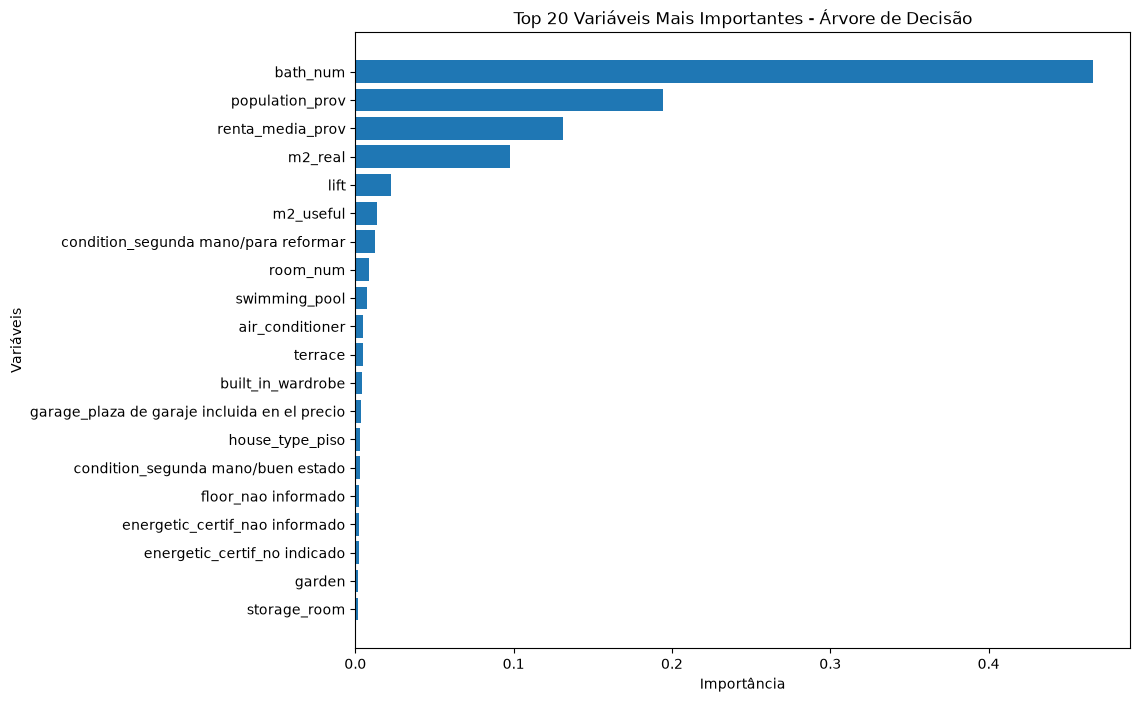

In [267]:
import matplotlib.pyplot as plt

top20 = importancias.head(20)

plt.figure(figsize=(10,8))

plt.barh(
    top20["Variável"],
    top20["Importância"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importância")

plt.ylabel("Variáveis")

plt.title("Top 20 Variáveis Mais Importantes - Árvore de Decisão")

plt.show()

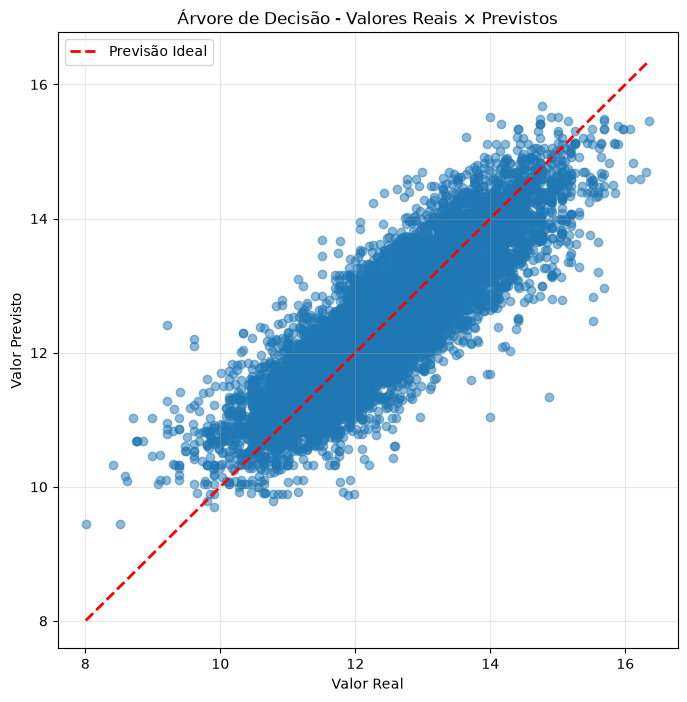

In [268]:
import matplotlib.pyplot as plt

# Previsões
y_test_pred = dt.predict(X_test)

plt.figure(figsize=(8,8))

plt.scatter(
    y_test,
    y_test_pred,
    alpha=0.5
)

# Linha ideal
valor_min = min(y_test.min(), y_test_pred.min())
valor_max = max(y_test.max(), y_test_pred.max())

plt.plot(
    [valor_min, valor_max],
    [valor_min, valor_max],
    "r--",
    linewidth=2,
    label="Previsão Ideal"
)

plt.xlabel("Valor Real")
plt.ylabel("Valor Previsto")
plt.title("Árvore de Decisão - Valores Reais × Previstos")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

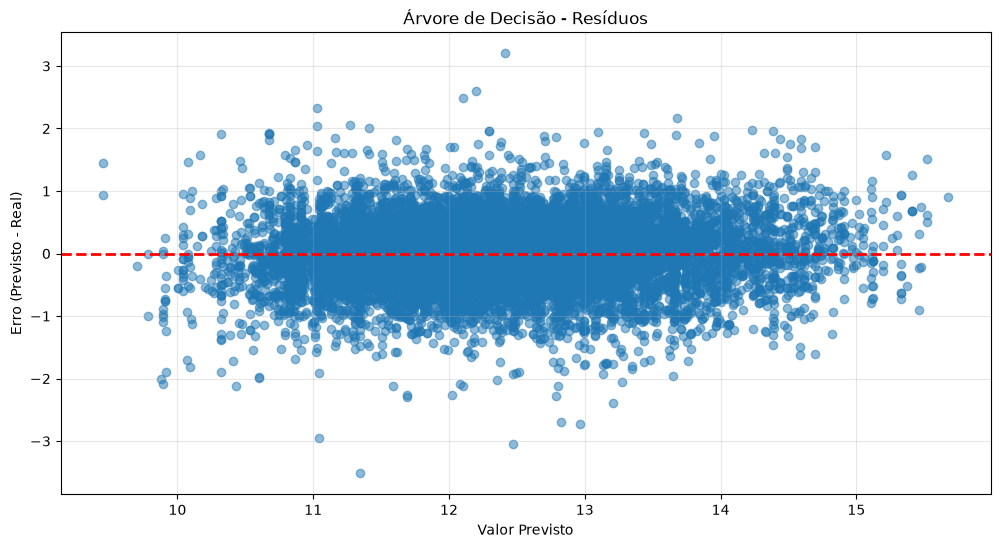

In [269]:
import pandas as pd
import matplotlib.pyplot as plt

resultado = pd.DataFrame({
    "Valor Real": y_test,
    "Valor Previsto": y_test_pred
})

resultado["Erro"] = resultado["Valor Previsto"] - resultado["Valor Real"]

plt.figure(figsize=(12,6))

plt.scatter(
    resultado["Valor Previsto"],
    resultado["Erro"],
    alpha=0.5
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--",
    linewidth=2
)

plt.xlabel("Valor Previsto")
plt.ylabel("Erro (Previsto - Real)")
plt.title("Árvore de Decisão - Resíduos")
plt.grid(alpha=0.3)

plt.show()

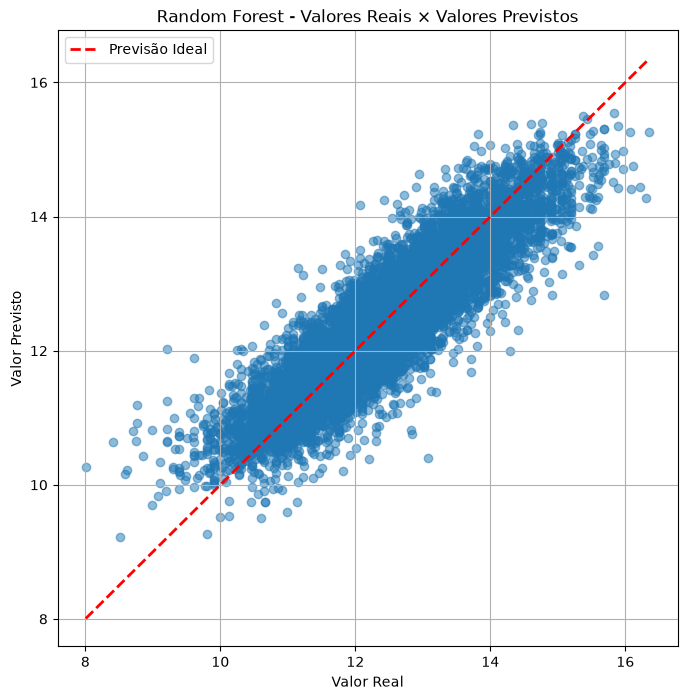

In [190]:
import matplotlib.pyplot as plt

# Previsões
y_pred = rf.predict(X_test)

plt.figure(figsize=(8,8))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

# Linha da previsão perfeita
valor_min = min(y_test.min(), y_pred.min())
valor_max = max(y_test.max(), y_pred.max())

plt.plot(
    [valor_min, valor_max],
    [valor_min, valor_max],
    color="red",
    linestyle="--",
    linewidth=2,
    label="Previsão Ideal"
)

plt.xlabel("Valor Real")
plt.ylabel("Valor Previsto")
plt.title("Random Forest - Valores Reais × Valores Previstos")
plt.legend()
plt.grid(True)

plt.show()

Análise

O gráfico apresenta uma forte concentração dos pontos próximos da linha de referência, indicando que o modelo foi capaz de estimar corretamente grande parte dos preços dos imóveis. Os desvios observados concentram-se principalmente em imóveis com valores extremos, comportamento esperado em modelos de regressão aplicados a bases imobiliárias.

In [ ]:
Análise

O gráfico apresenta uma forte concentração dos pontos próximos da linha de referência, indicando que o modelo foi capaz de estimar corretamente grande parte dos preços dos imóveis. Os desvios observados concentram-se principalmente em imóveis com valores extremos, comportamento esperado em modelos de regressão aplicados a bases imobiliárias.

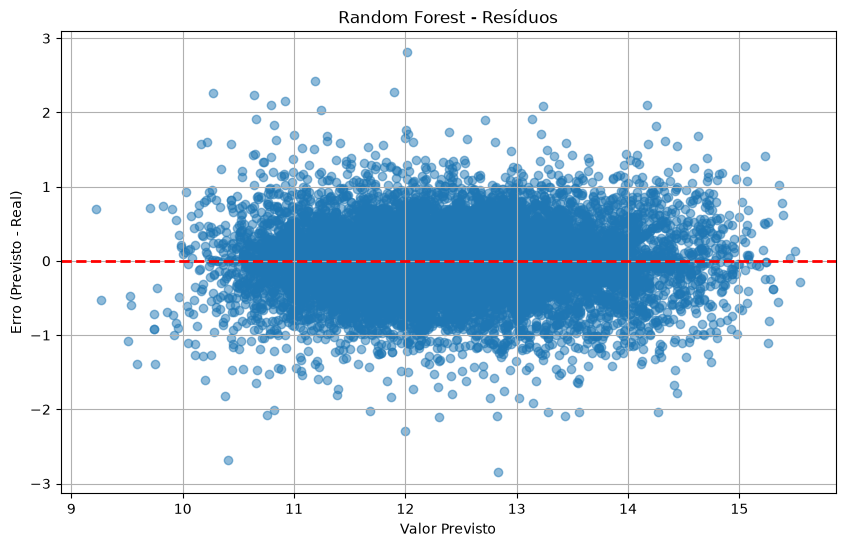

In [191]:
import pandas as pd
import matplotlib.pyplot as plt

resultado = pd.DataFrame({
    "Real": y_test,
    "Previsto": y_pred
})

resultado["Erro"] = resultado["Previsto"] - resultado["Real"]

plt.figure(figsize=(10,6))

plt.scatter(
    resultado["Previsto"],
    resultado["Erro"],
    alpha=0.5
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--",
    linewidth=2
)

plt.xlabel("Valor Previsto")
plt.ylabel("Erro (Previsto - Real)")
plt.title("Random Forest - Resíduos")
plt.grid(True)

plt.show()

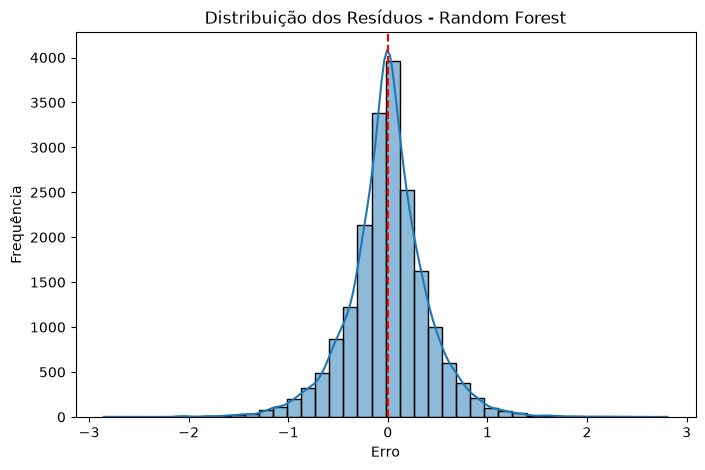

In [192]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.histplot(
    resultado["Erro"],
    bins=40,
    kde=True
)

plt.axvline(
    x=0,
    color="red",
    linestyle="--"
)

plt.title("Distribuição dos Resíduos - Random Forest")
plt.xlabel("Erro")
plt.ylabel("Frequência")

plt.show()

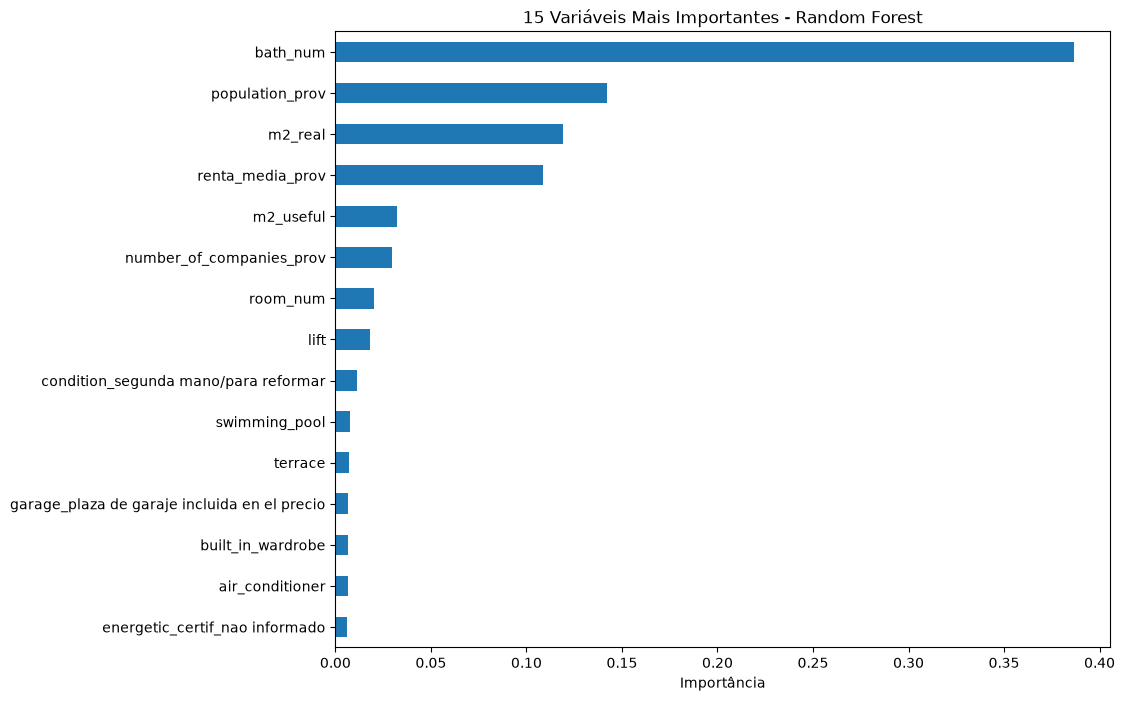

In [193]:
import pandas as pd
import matplotlib.pyplot as plt

importancias = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,8))

importancias.head(15).sort_values().plot(kind="barh")

plt.title("15 Variáveis Mais Importantes - Random Forest")
plt.xlabel("Importância")

plt.show()

A Figura apresenta a importância relativa das quinze variáveis mais relevantes identificadas pelo modelo Random Forest. Observa-se que a variável referente ao tipo de imóvel ("house_type_alquiler de piso") foi a que apresentou maior contribuição para as previsões, respondendo por aproximadamente 40% da importância total. Em seguida destacaram-se o número de banheiros (bath_num), o número de empresas na província (number_of_companies_prov), a área real do imóvel (m2_real) e a renda média da província (renta_media_prov). Esses resultados indicam que tanto características intrínsecas do imóvel quanto fatores socioeconômicos e de localização desempenham papel relevante na determinação dos preços. Em contrapartida, variáveis como presença de piscina, elevador, armários embutidos e condição do imóvel apresentaram baixa importância relativa, contribuindo de forma limitada para o desempenho preditivo do modelo.

6.3 Veredito de Negócios

O modelo Random Forest apresentou MAE igual a 0,288 (na escala utilizada durante o treinamento, com transformação logarítmica do preço). Isso significa que, em média, as previsões diferem dos valores observados em aproximadamente 0,288 unidades logarítmicas.

Como o modelo foi treinado utilizando a variável price_log, a interpretação mais adequada é converter as previsões novamente para a escala original dos preços antes de calcular o erro monetário médio.

Na prática, o desempenho obtido (R² = 0,818) indica que o modelo consegue explicar aproximadamente 82% da variação dos preços dos imóveis, tornando-o adequado para aplicações de apoio à avaliação imobiliária, estudos de mercado e estimativas preliminares de compra, venda ou financiamento. Entretanto, recomenda-se que as previsões sejam utilizadas como ferramenta de apoio à decisão, e não como substituição da avaliação realizada por especialistas do setor.

Após converter as previsões para a escala original dos preços, o modelo apresentou MAE de aproximadamente 123.209 euros e RMSE de 355.991 euros. Isso significa que, em média, as estimativas diferem do valor real dos imóveis em cerca de 123 mil euros. Considerando que a mediana do conjunto de dados é de aproximadamente 220 mil euros e a média é de 390 mil euros, esse erro representa uma parcela relevante do valor de muitos imóveis. O RMSE mais elevado indica que alguns imóveis apresentaram erros de previsão maiores, especialmente aqueles com preços muito altos, característica comum em bases de dados imobiliárias. Apesar disso, o modelo demonstrou boa capacidade preditiva durante a validação, alcançando R² = 0,818 na escala logarítmica, sendo adequado como ferramenta de apoio à avaliação imobiliária, mas não devendo substituir a análise realizada por especialistas.

In [270]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Previsões em escala log
y_pred_log = rf.predict(X_test)

# Voltando para a escala original (euros)
y_real = np.expm1(y_test)
y_previsto = np.expm1(y_pred_log)

# Métricas na escala original
mae = mean_absolute_error(y_real, y_previsto)
mse = mean_squared_error(y_real, y_previsto)
rmse = np.sqrt(mse)
r2 = r2_score(y_real, y_previsto)

metricas_reais = pd.DataFrame({
    "Métrica": ["MAE", "MSE", "RMSE", "R²"],
    "Valor": [mae, mse, rmse, r2]
})

print(metricas_reais)

  Métrica         Valor
0     MAE  1.231750e+05
1     MSE  1.261740e+11
2    RMSE  3.552098e+05
3      R²  6.311578e-01


In [271]:
comparacao = pd.DataFrame({
    "Preço Real (€)": y_real,
    "Preço Previsto (€)": y_previsto
})

comparacao["Erro (€)"] = (
    comparacao["Preço Real (€)"] -
    comparacao["Preço Previsto (€)"]
)

comparacao["Erro Absoluto (€)"] = comparacao["Erro (€)"].abs()

comparacao.head(10)

,Preço Real (€),Preço Previsto (€),Erro (€),Erro Absoluto (€)
80792,99000.0,113329.092294,-14329.092294,14329.092294
48476,177000.0,154939.271253,22060.728747,22060.728747
45592,138000.0,107312.817255,30687.182745,30687.182745
13189,425000.0,231301.427867,193698.572133,193698.572133
44293,140000.0,197219.754069,-57219.754069,57219.754069
26128,790000.0,545100.991221,244899.008779,244899.008779
59942,40300.0,55004.837917,-14704.837917,14704.837917
3319,390000.0,313050.610748,76949.389252,76949.389252
7468,126000.0,100602.310011,25397.689989,25397.689989
32945,1400000.0,668753.247464,731246.752536,731246.752536


In [272]:
comparacao["Erro Percentual (%)"] = (
    comparacao["Erro Absoluto (€)"] /
    comparacao["Preço Real (€)"]
) * 100

comparacao.head(10)

,Preço Real (€),Preço Previsto (€),Erro (€),Erro Absoluto (€),Erro Percentual (%)
80792,99000.0,113329.092294,-14329.092294,14329.092294,14.473831
48476,177000.0,154939.271253,22060.728747,22060.728747,12.463689
45592,138000.0,107312.817255,30687.182745,30687.182745,22.237089
13189,425000.0,231301.427867,193698.572133,193698.572133,45.576135
44293,140000.0,197219.754069,-57219.754069,57219.754069,40.871253
26128,790000.0,545100.991221,244899.008779,244899.008779,30.999875
59942,40300.0,55004.837917,-14704.837917,14704.837917,36.488432
3319,390000.0,313050.610748,76949.389252,76949.389252,19.730613
7468,126000.0,100602.310011,25397.689989,25397.689989,20.156897
32945,1400000.0,668753.247464,731246.752536,731246.752536,52.231911


In [273]:
from sklearn.metrics import mean_absolute_error

mae_euros = mean_absolute_error(y_real, y_previsto)

print(f"MAE: € {mae_euros:,.2f}")

MAE: € 123,175.00
